# Early Exit Results Analysis


## Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Load Early Exit Parquet


In [2]:
from pathlib import Path

H1_EXIT_PATH = Path('../data/dataset/h1_exit_df.parquet')

print('Using:', H1_EXIT_PATH)
exit_df = pd.read_parquet(H1_EXIT_PATH)
exit_df.head()


Using: ../data/dataset/h1_exit_df.parquet


,date,ticker,p_up_1d_LSTM,p_up_1d_BiLSTM,p_up_1d_GRU,p_up_1d_BiGRU,reg_dir_LSTM,reg_conf_LSTM,reg_dir_BiLSTM,reg_conf_BiLSTM,reg_dir_GRU,reg_conf_GRU,reg_dir_BiGRU,reg_conf_BiGRU,p_up_1d
0,2017-04-11,AAPL,0.412533,0.181657,0.073817,0.267304,-1,0.027108,1,0.078051,-1,0.065142,-1,0.159865,0.267304
1,2017-04-11,ABB,0.391336,0.213102,0.035350,0.131257,1,0.022468,-1,0.065416,-1,0.067507,-1,0.039466,0.131257
2,2017-04-11,ABBV,0.347729,0.484376,0.386789,0.565157,1,0.039871,-1,0.149188,1,0.116767,1,0.014574,0.565157
3,2017-04-11,AEP,0.478586,0.521852,0.372779,0.423827,-1,0.010143,1,0.005481,1,0.032548,-1,0.092777,0.423827
4,2017-04-11,AGFS,0.479339,0.383718,0.397609,0.391693,-1,0.016668,1,0.014681,-1,0.063929,1,0.156522,0.391693


## Basic Overview


In [3]:
print('Shape:', exit_df.shape)
print('Columns:', exit_df.columns.tolist())
print('Date range:', exit_df['date'].min(), '->', exit_df['date'].max())
print('Unique tickers:', exit_df['ticker'].nunique())
print('Rows per date (describe):')
print(exit_df.groupby('date').size().describe())
print('Rows per ticker (describe):')
print(exit_df.groupby('ticker').size().describe())


Shape: (8800, 15)
Columns: ['date', 'ticker', 'p_up_1d_LSTM', 'p_up_1d_BiLSTM', 'p_up_1d_GRU', 'p_up_1d_BiGRU', 'reg_dir_LSTM', 'reg_conf_LSTM', 'reg_dir_BiLSTM', 'reg_conf_BiLSTM', 'reg_dir_GRU', 'reg_conf_GRU', 'reg_dir_BiGRU', 'reg_conf_BiGRU', 'p_up_1d']
Date range: 2017-04-11 00:00:00 -> 2017-08-31 00:00:00
Unique tickers: 88
Rows per date (describe):
count    100.0
mean      88.0
std        0.0
min       88.0
25%       88.0
50%       88.0
75%       88.0
max       88.0
dtype: float64
Rows per ticker (describe):
count     88.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


## Missingness


In [4]:
missing = exit_df.isna().mean().sort_values(ascending=False)
print(missing)
if missing.max() > 0:
    missing[missing > 0].plot(kind='bar')
    plt.title('Missing Fraction by Column')
    plt.ylabel('Missing Fraction')
    plt.show()


date               0.0
ticker             0.0
p_up_1d_LSTM       0.0
p_up_1d_BiLSTM     0.0
p_up_1d_GRU        0.0
p_up_1d_BiGRU      0.0
reg_dir_LSTM       0.0
reg_conf_LSTM      0.0
reg_dir_BiLSTM     0.0
reg_conf_BiLSTM    0.0
reg_dir_GRU        0.0
reg_conf_GRU       0.0
reg_dir_BiGRU      0.0
reg_conf_BiGRU     0.0
p_up_1d            0.0
dtype: float64


## Coverage by Date and Ticker


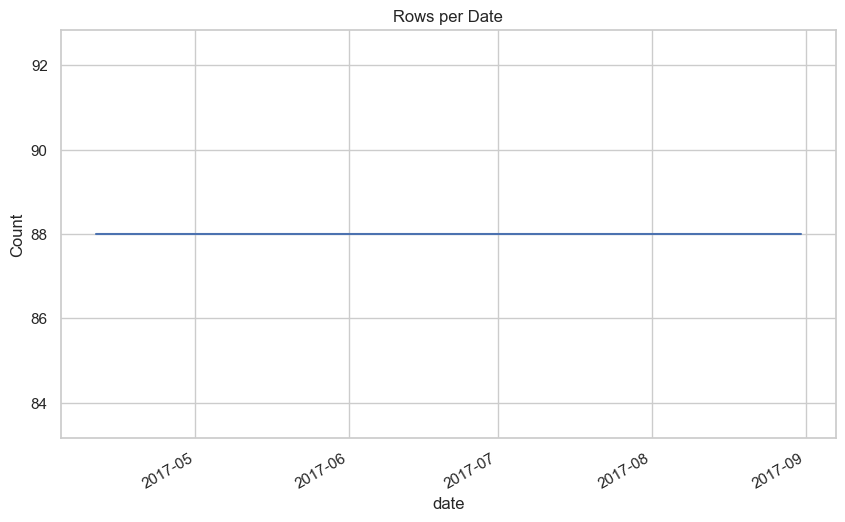

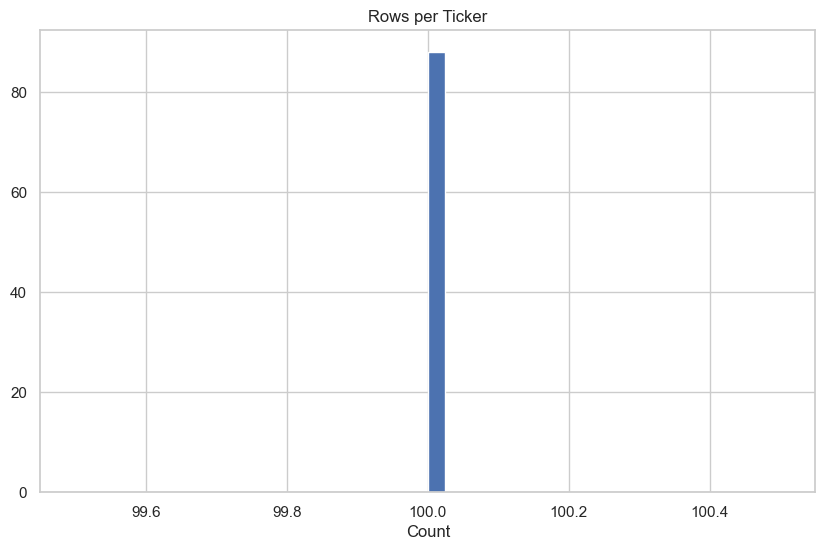

In [5]:
per_date = exit_df.groupby('date').size()
per_ticker = exit_df.groupby('ticker').size()
per_date.plot(kind='line')
plt.title('Rows per Date')
plt.ylabel('Count')
plt.show()

per_ticker.hist(bins=40)
plt.title('Rows per Ticker')
plt.xlabel('Count')
plt.show()


## Probability Distributions (Classification)


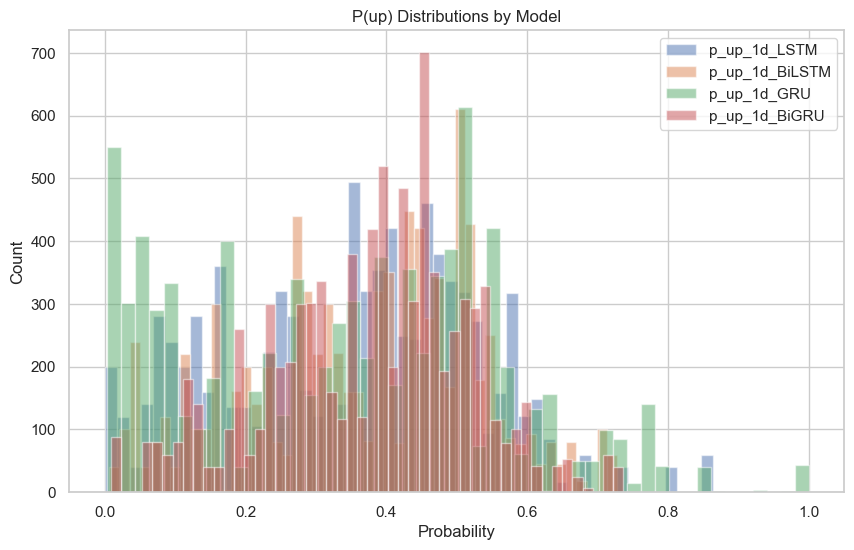

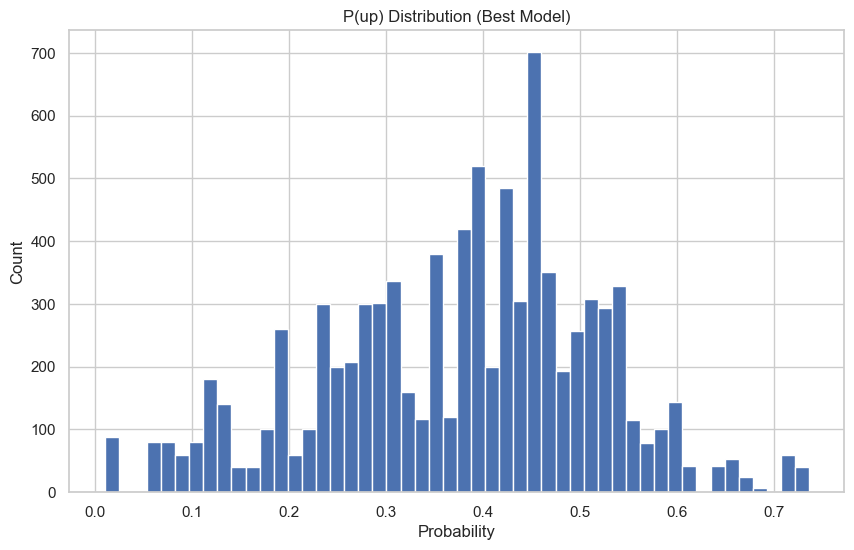

In [6]:
prob_cols = [c for c in exit_df.columns if c.startswith('p_up_1d_') and c != 'p_up_1d']
for c in prob_cols:
    exit_df[c].dropna().hist(bins=50, alpha=0.5, label=c)
if prob_cols:
    plt.title('P(up) Distributions by Model')
    plt.xlabel('Probability')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

if 'p_up_1d' in exit_df.columns:
    exit_df['p_up_1d'].dropna().hist(bins=50)
    plt.title('P(up) Distribution (Best Model)')
    plt.xlabel('Probability')
    plt.ylabel('Count')
    plt.show()


## Model Agreement (Classification)


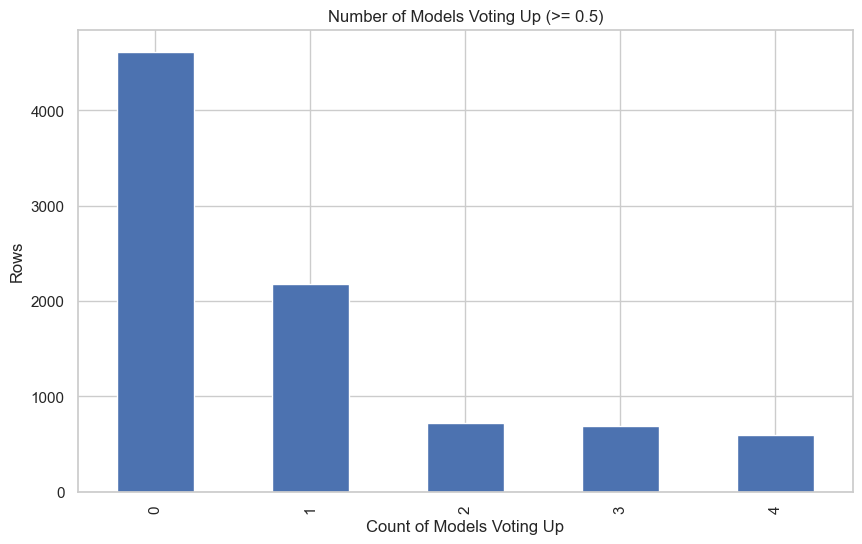

In [7]:
prob_cols = [c for c in exit_df.columns if c.startswith('p_up_1d_') and c != 'p_up_1d']
if prob_cols:
    votes = (exit_df[prob_cols] >= 0.5).sum(axis=1)
    votes.value_counts().sort_index().plot(kind='bar')
    plt.title('Number of Models Voting Up (>= 0.5)')
    plt.xlabel('Count of Models Voting Up')
    plt.ylabel('Rows')
    plt.show()


## Regression Direction + Confidence


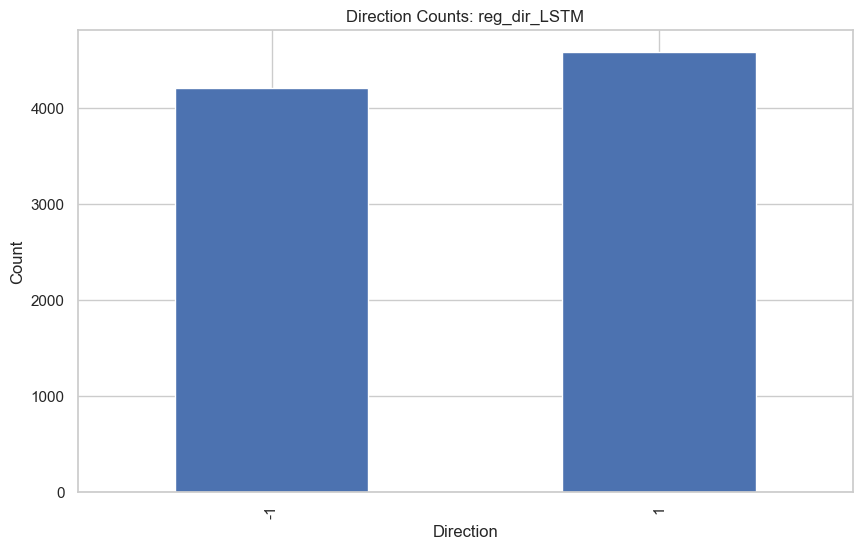

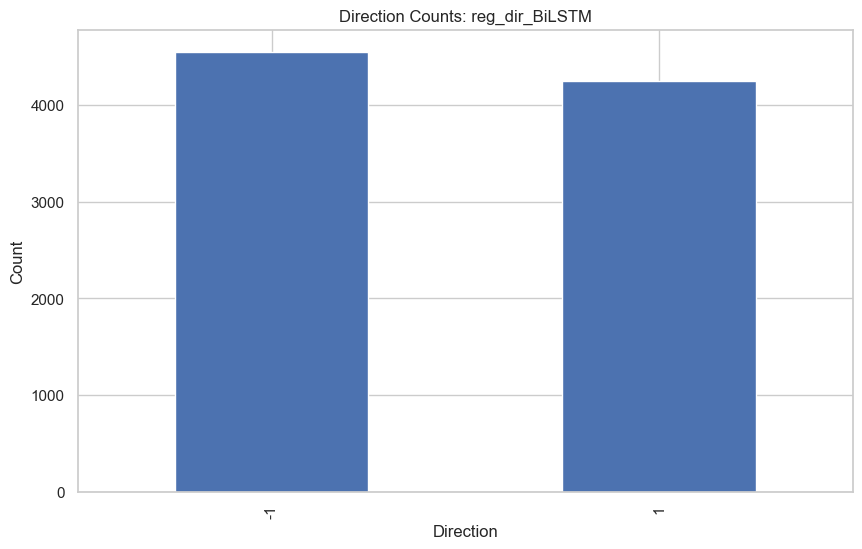

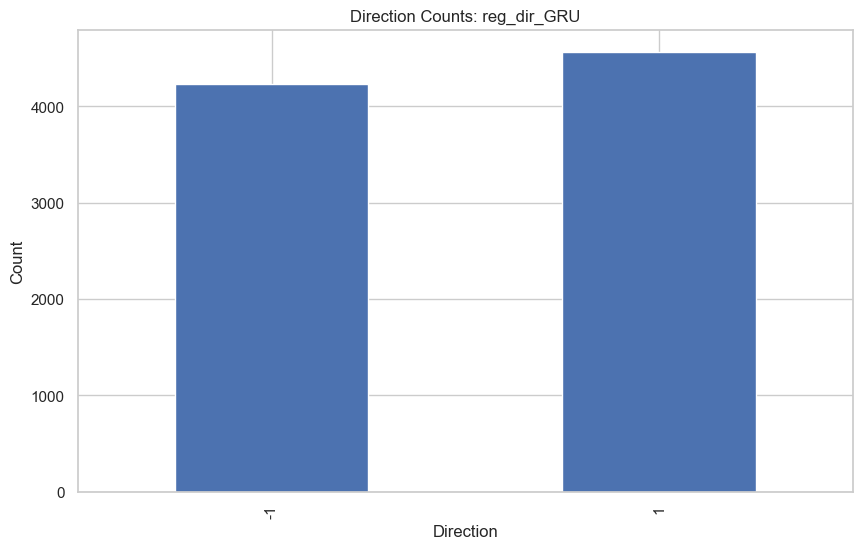

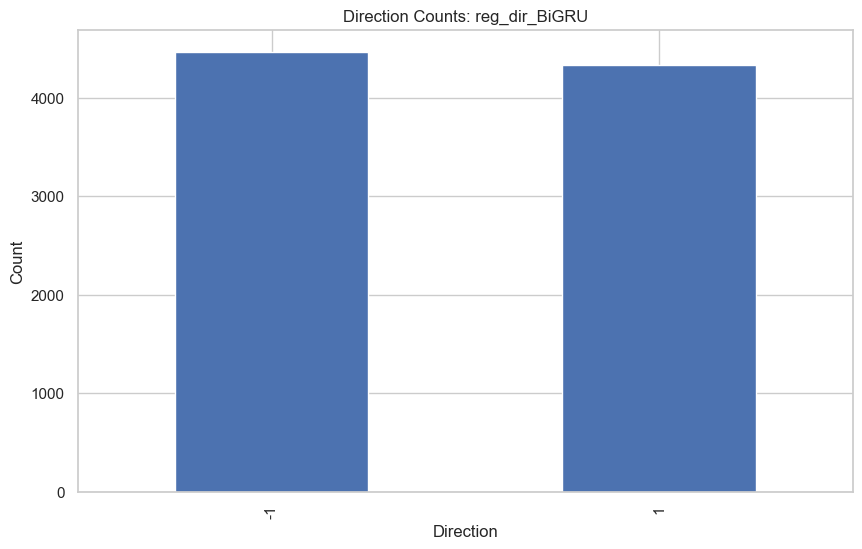

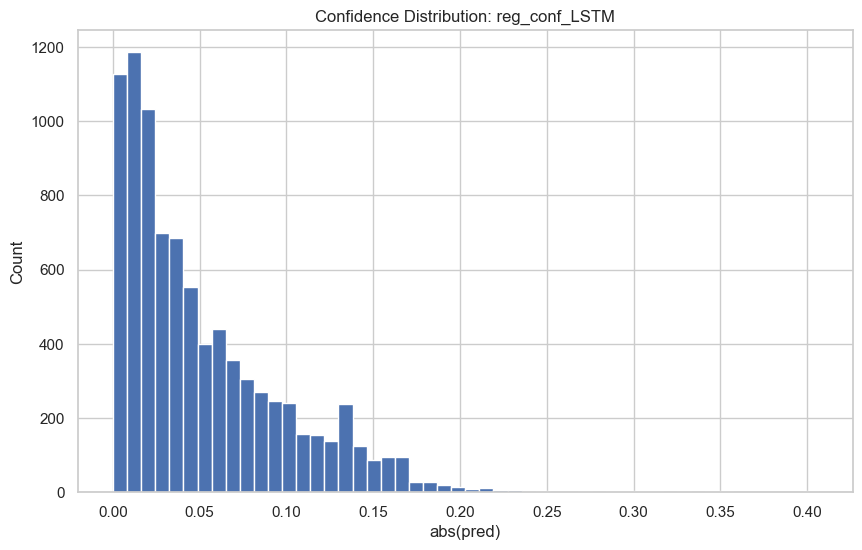

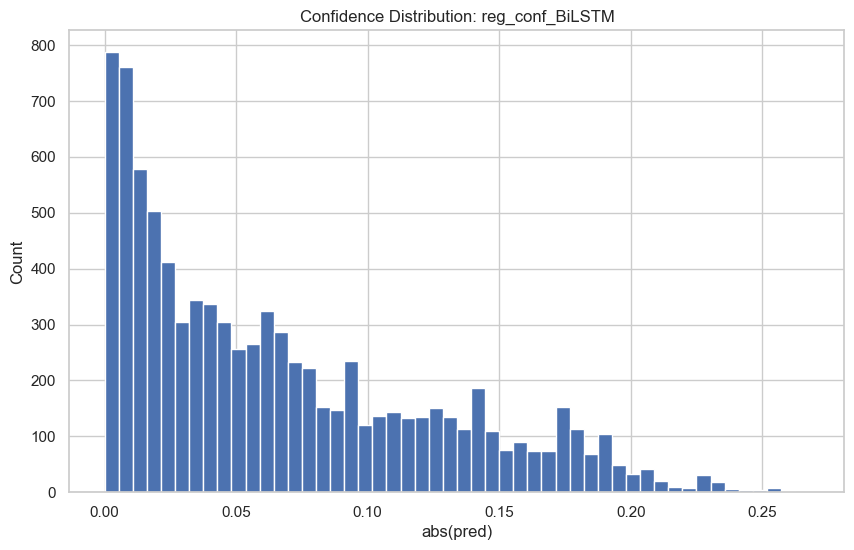

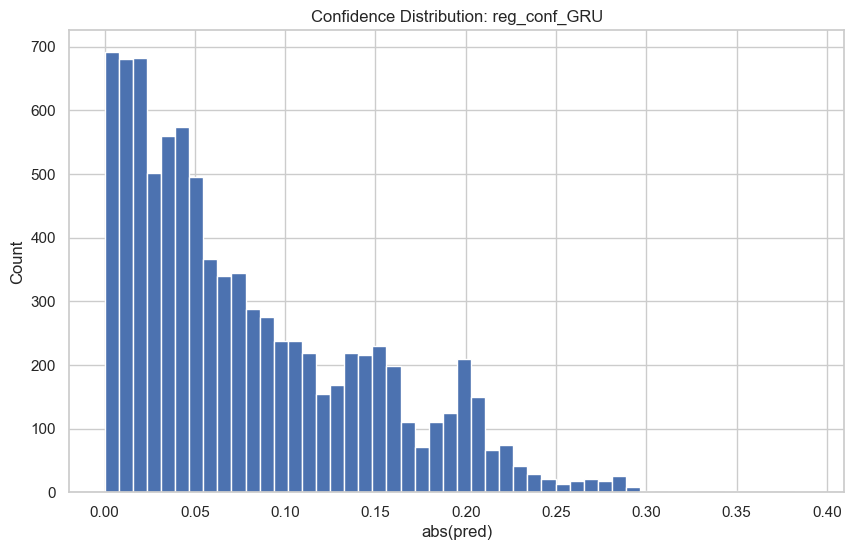

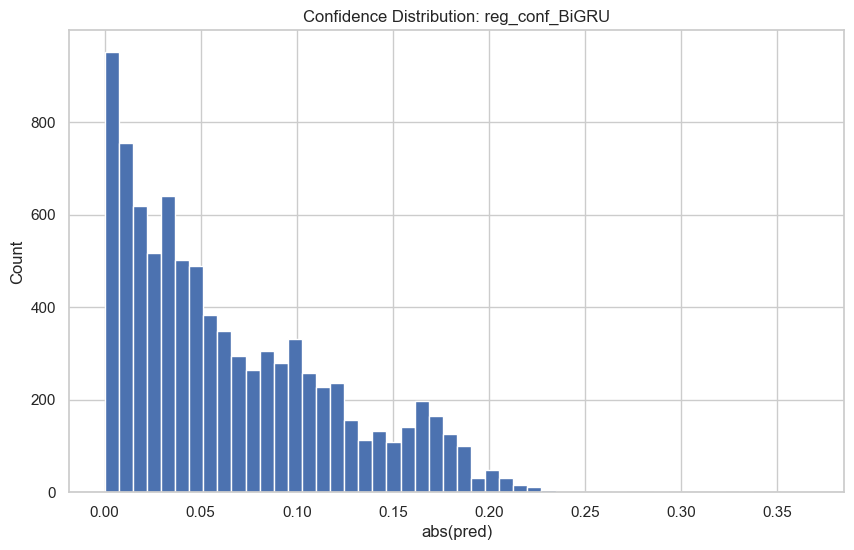

In [8]:
dir_cols = [c for c in exit_df.columns if c.startswith('reg_dir_')]
conf_cols = [c for c in exit_df.columns if c.startswith('reg_conf_')]
for c in dir_cols:
    exit_df[c].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Direction Counts: {c}')
    plt.xlabel('Direction')
    plt.ylabel('Count')
    plt.show()

for c in conf_cols:
    exit_df[c].dropna().hist(bins=50)
    plt.title(f'Confidence Distribution: {c}')
    plt.xlabel('abs(pred)')
    plt.ylabel('Count')
    plt.show()


## Cross-Model Correlations


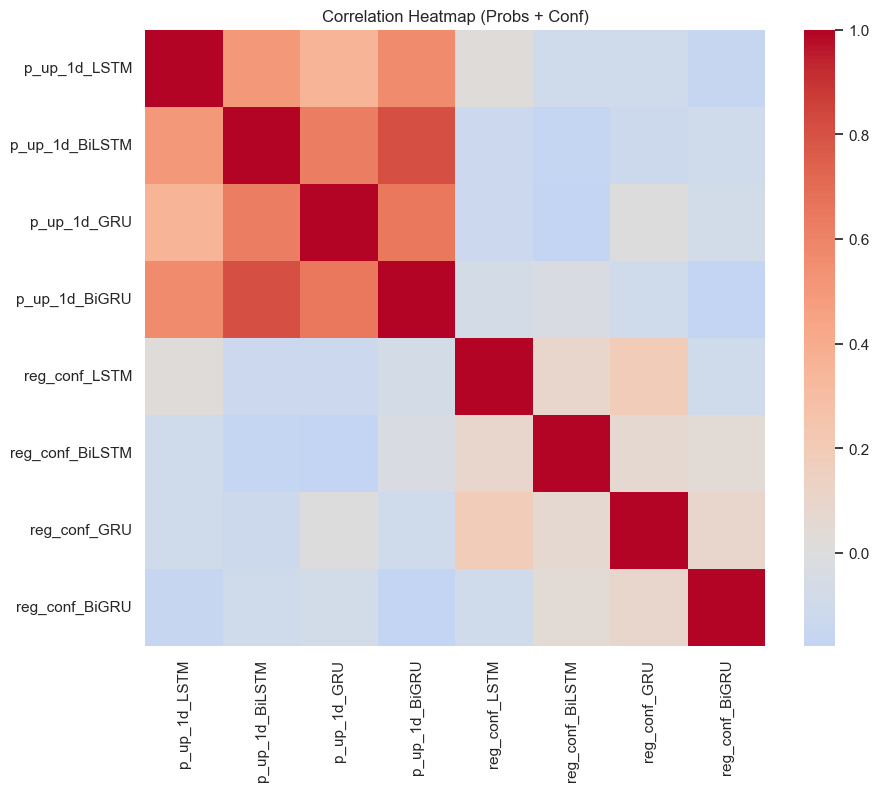

In [9]:
corr_cols = [c for c in exit_df.columns if c.startswith('p_up_1d_')] + [c for c in exit_df.columns if c.startswith('reg_conf_')]
corr_cols = [c for c in corr_cols if c in exit_df.columns]
if corr_cols:
    corr = exit_df[corr_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Probs + Conf)')
    plt.show()


## Time Series: Mean P(up) Across Tickers


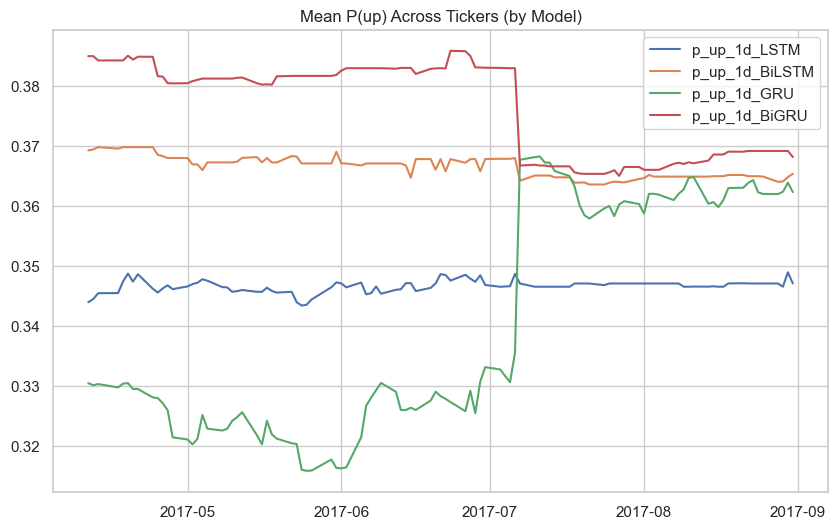

In [10]:
prob_cols = [c for c in exit_df.columns if c.startswith('p_up_1d_') and c != 'p_up_1d']
if prob_cols:
    for c in prob_cols:
        series = exit_df.groupby('date')[c].mean()
        plt.plot(series.index, series.values, label=c)
    plt.title('Mean P(up) Across Tickers (by Model)')
    plt.legend()
    plt.show()


## Optional: Merge with master_df to Evaluate Accuracy


    model  accuracy
0    LSTM  0.477045
2     GRU  0.475682
1  BiLSTM  0.472273
3   BiGRU  0.466932


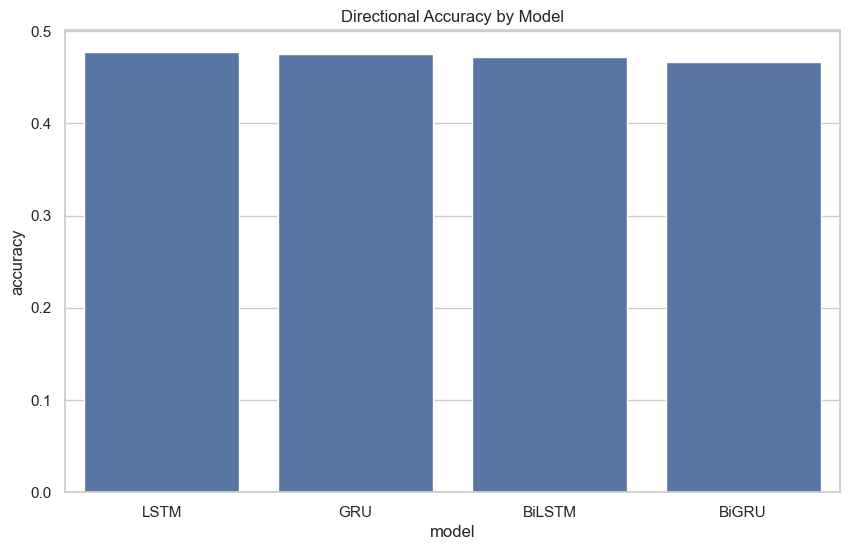

In [11]:
MASTER_PATH = Path('../data/dataset/master_df.parquet')
if MASTER_PATH.exists():
    master_df = pd.read_parquet(MASTER_PATH)
    master_df = master_df.sort_values(['date','ticker']).copy()
    master_df['next_day_close'] = master_df.groupby('ticker')['close'].shift(-1)
    master_df['actual_direction'] = (master_df['next_day_close'] > master_df['close']).astype(int)
    eval_df = exit_df.merge(master_df[['date','ticker','actual_direction']], on=['date','ticker'], how='left')
    prob_cols = [c for c in exit_df.columns if c.startswith('p_up_1d_') and c != 'p_up_1d']
    results = []
    for c in prob_cols:
        sub = eval_df[[c,'actual_direction']].dropna()
        if sub.empty:
            continue
        pred = (sub[c] >= 0.5).astype(int)
        acc = (pred == sub['actual_direction']).mean()
        results.append({'model': c.replace('p_up_1d_',''), 'accuracy': acc})
    if results:
        res_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
        print(res_df)
        sns.barplot(data=res_df, x='model', y='accuracy')
        plt.title('Directional Accuracy by Model')
        plt.show()
else:
    print('master_df.parquet not found; skipping accuracy eval.')


## Optional: Confidence vs Accuracy (Regression Direction)


/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_56160/1525222458.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = sub.groupby('conf_bin')['correct'].mean()


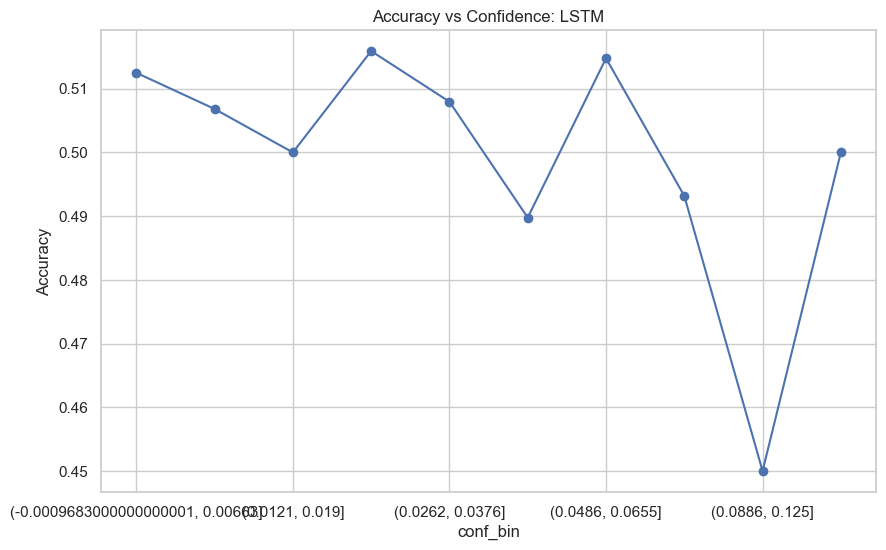

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_56160/1525222458.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = sub.groupby('conf_bin')['correct'].mean()


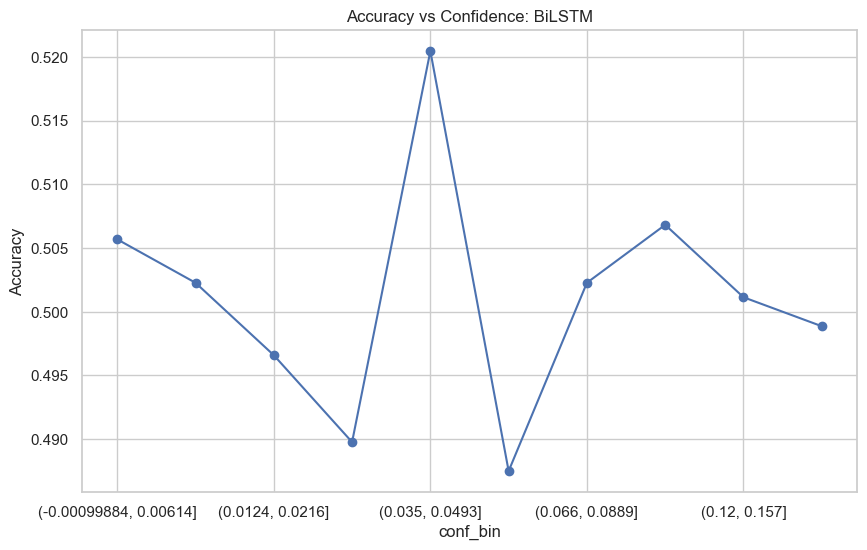

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_56160/1525222458.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = sub.groupby('conf_bin')['correct'].mean()


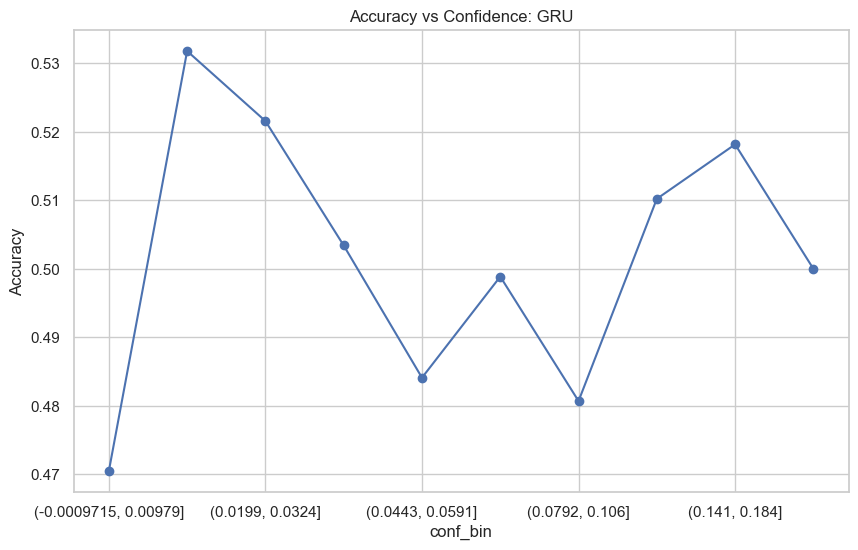

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_56160/1525222458.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = sub.groupby('conf_bin')['correct'].mean()


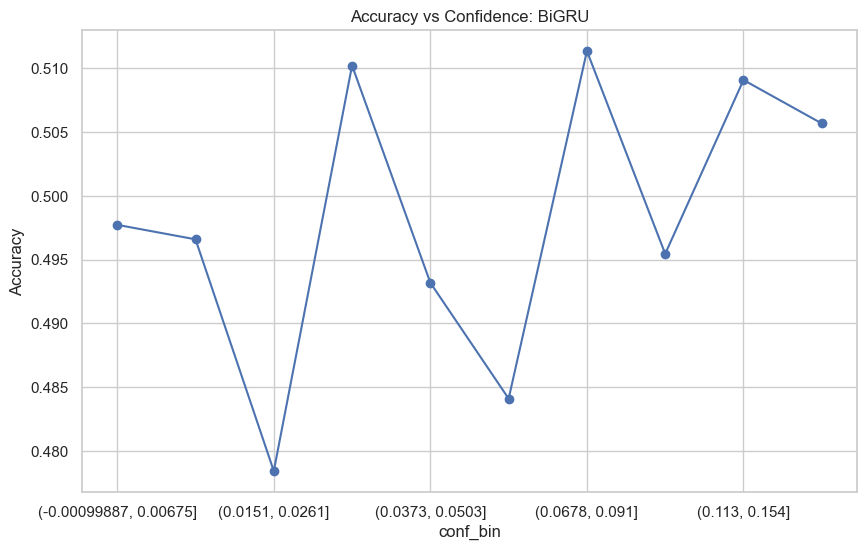

In [12]:
MASTER_PATH = Path('../data/dataset/master_df.parquet')
if MASTER_PATH.exists():
    master_df = pd.read_parquet(MASTER_PATH)
    master_df = master_df.sort_values(['date','ticker']).copy()
    master_df['next_day_close'] = master_df.groupby('ticker')['close'].shift(-1)
    master_df['actual_direction'] = (master_df['next_day_close'] > master_df['close']).astype(int)
    eval_df = exit_df.merge(master_df[['date','ticker','actual_direction']], on=['date','ticker'], how='left')
    for m in ['LSTM','BiLSTM','GRU','BiGRU']:
        dir_col = f'reg_dir_{m}'
        conf_col = f'reg_conf_{m}'
        if dir_col not in eval_df.columns or conf_col not in eval_df.columns:
            continue
        sub = eval_df[[dir_col, conf_col, 'actual_direction']].dropna()
        if sub.empty:
            continue
        # Convert dir (-1/1) to 0/1 for comparison
        pred_dir = (sub[dir_col] > 0).astype(int)
        sub = sub.assign(pred_dir=pred_dir)
        sub['correct'] = (sub['pred_dir'] == sub['actual_direction']).astype(int)
        sub['conf_bin'] = pd.qcut(sub[conf_col], q=10, duplicates='drop')
        acc_by_bin = sub.groupby('conf_bin')['correct'].mean()
        acc_by_bin.plot(kind='line', marker='o')
        plt.title(f'Accuracy vs Confidence: {m}')
        plt.ylabel('Accuracy')
        plt.show()
else:
    print('master_df.parquet not found; skipping confidence eval.')


## Early Exit Signal vs Actual Return (Sample by Sector)


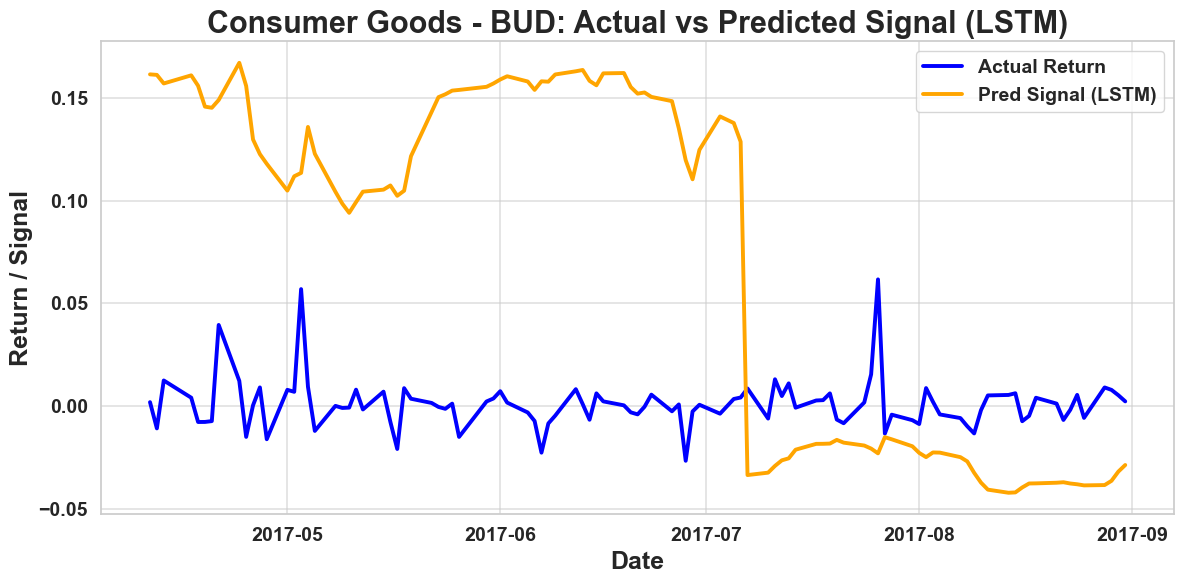

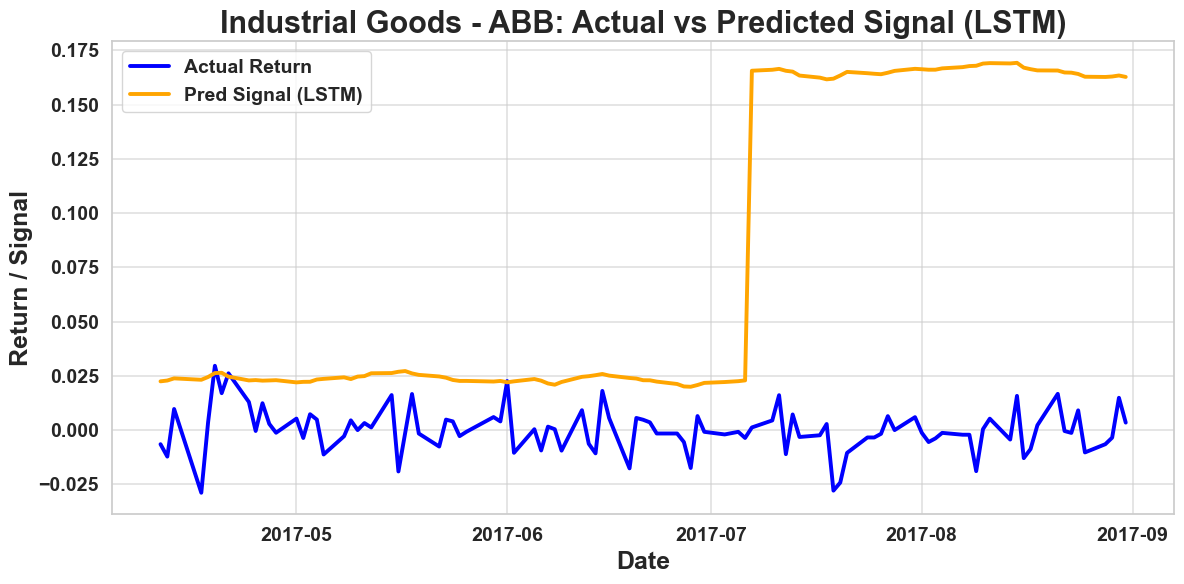

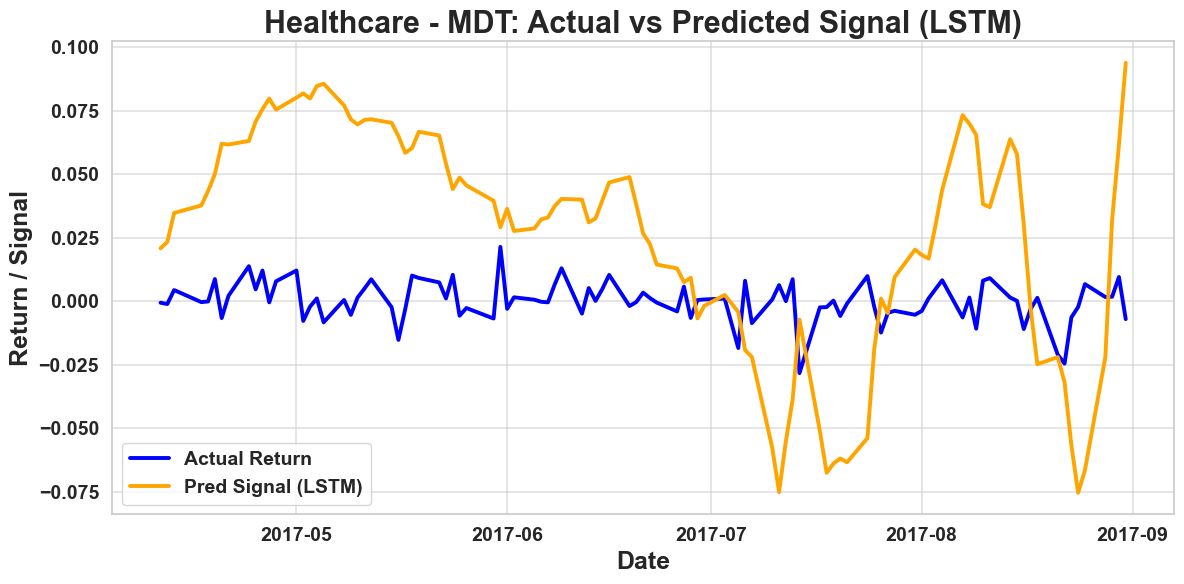

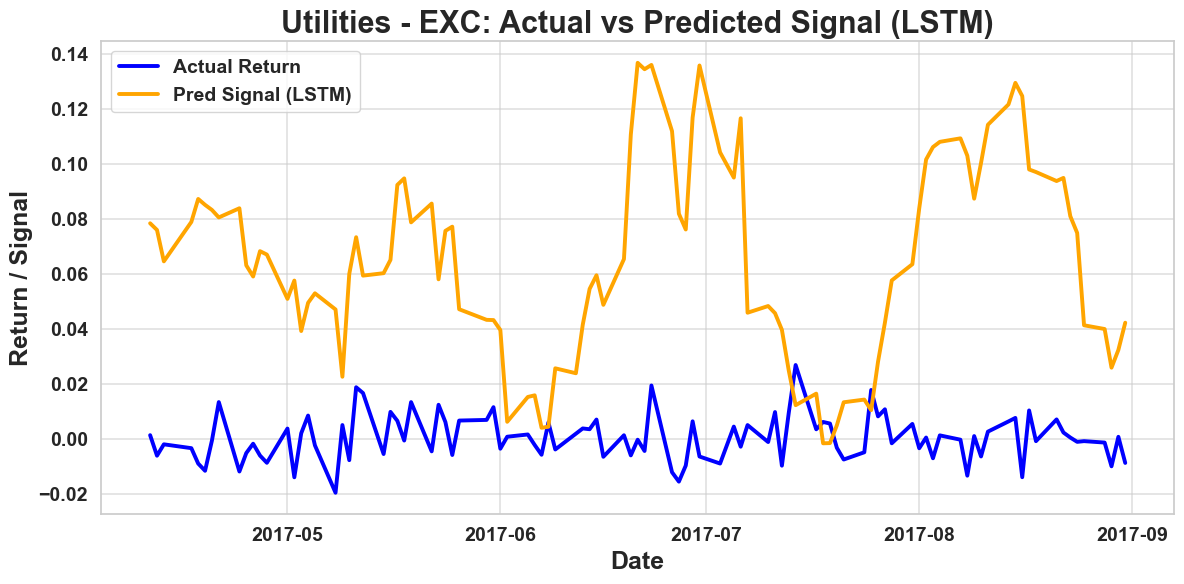

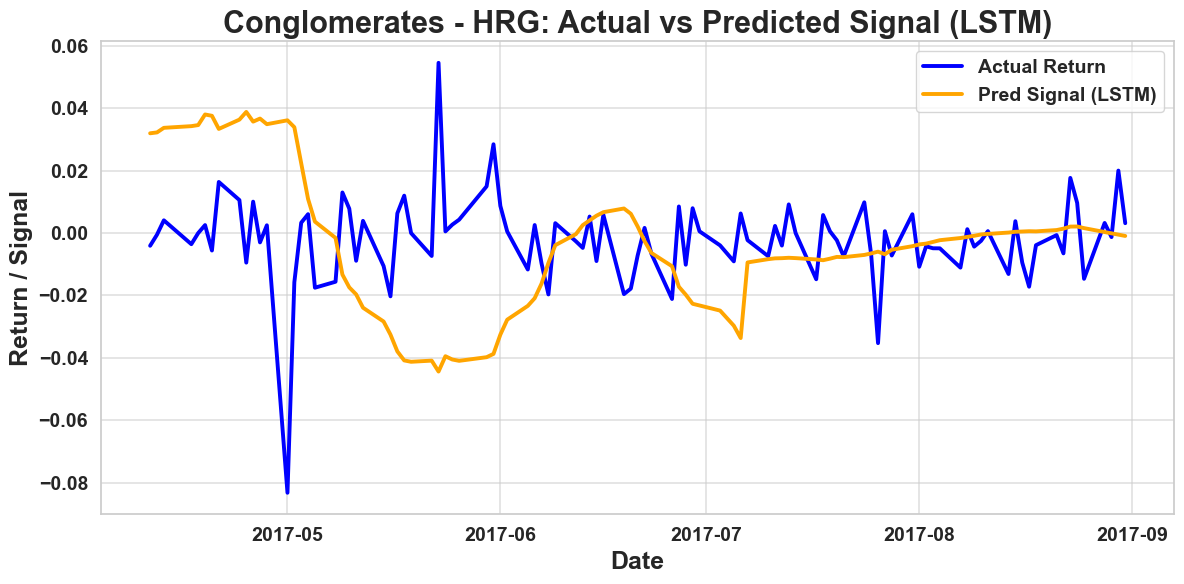

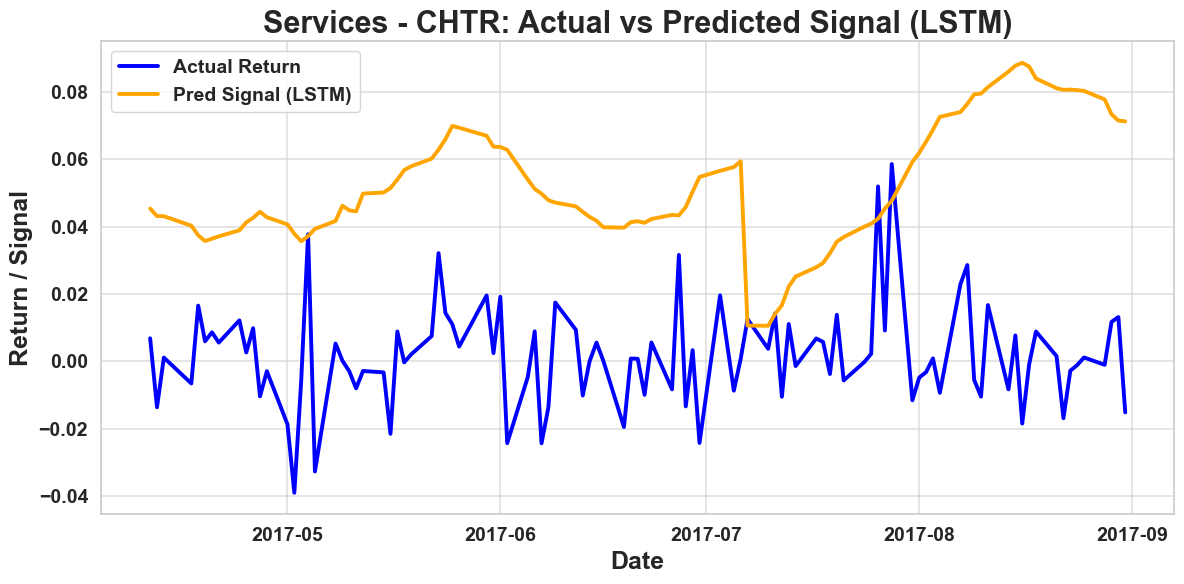

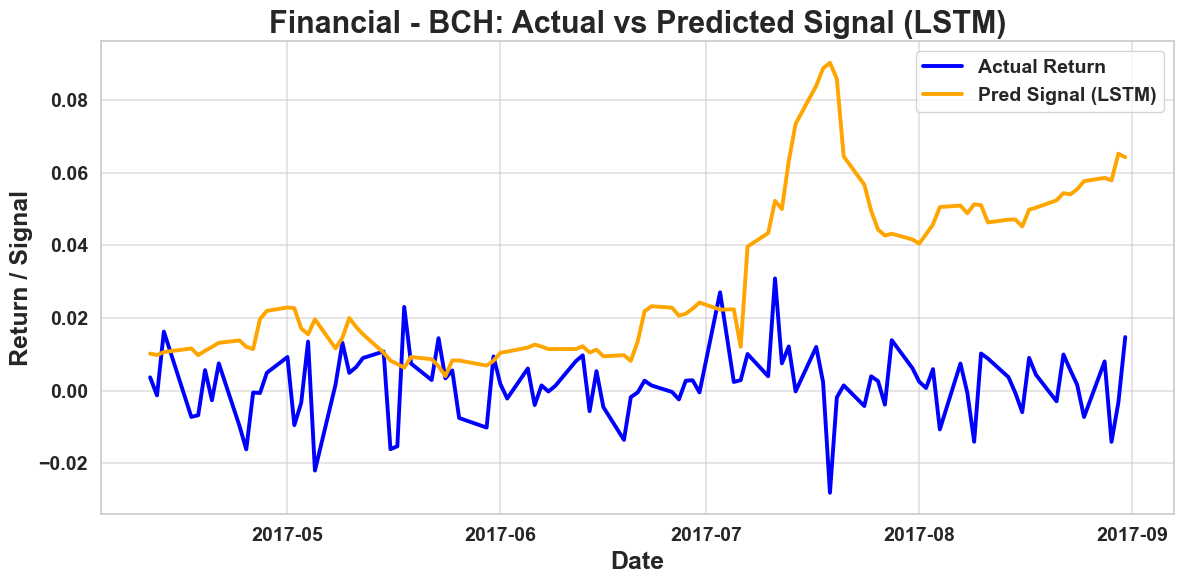

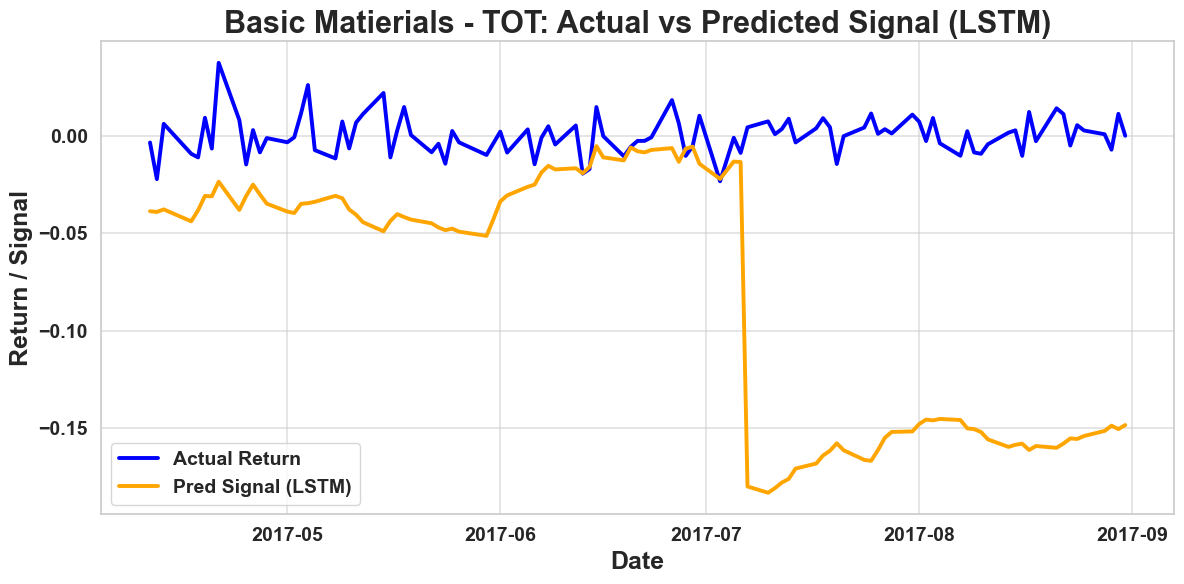

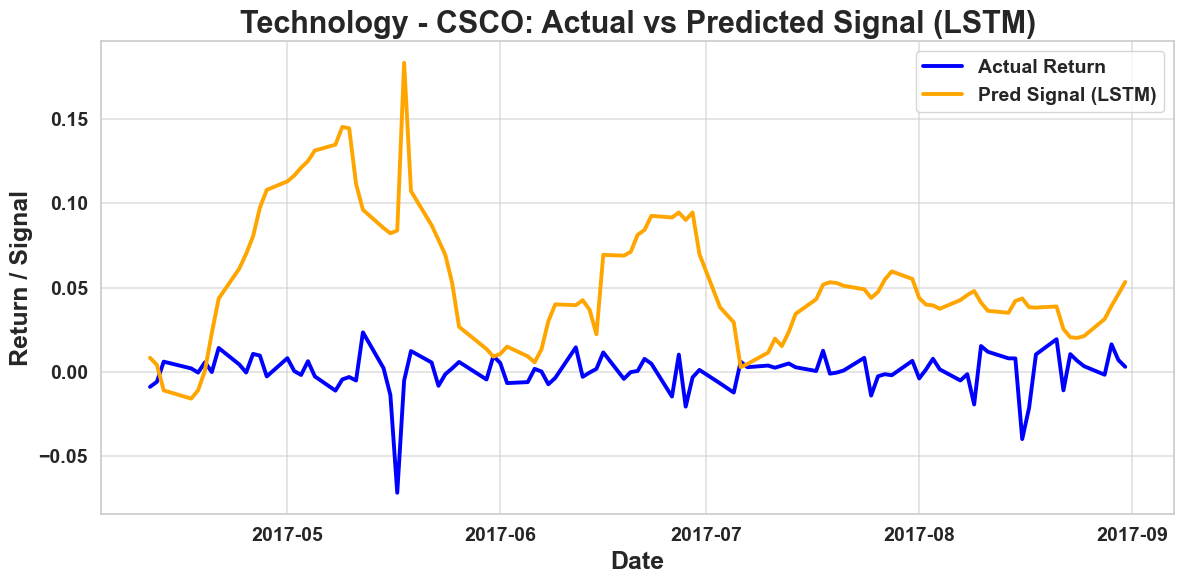

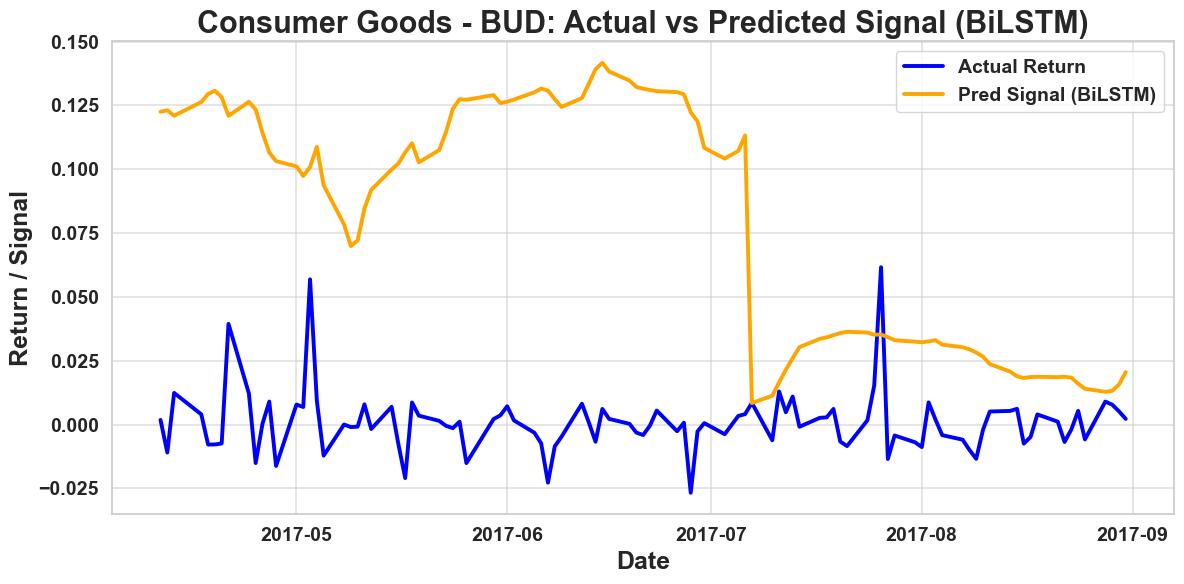

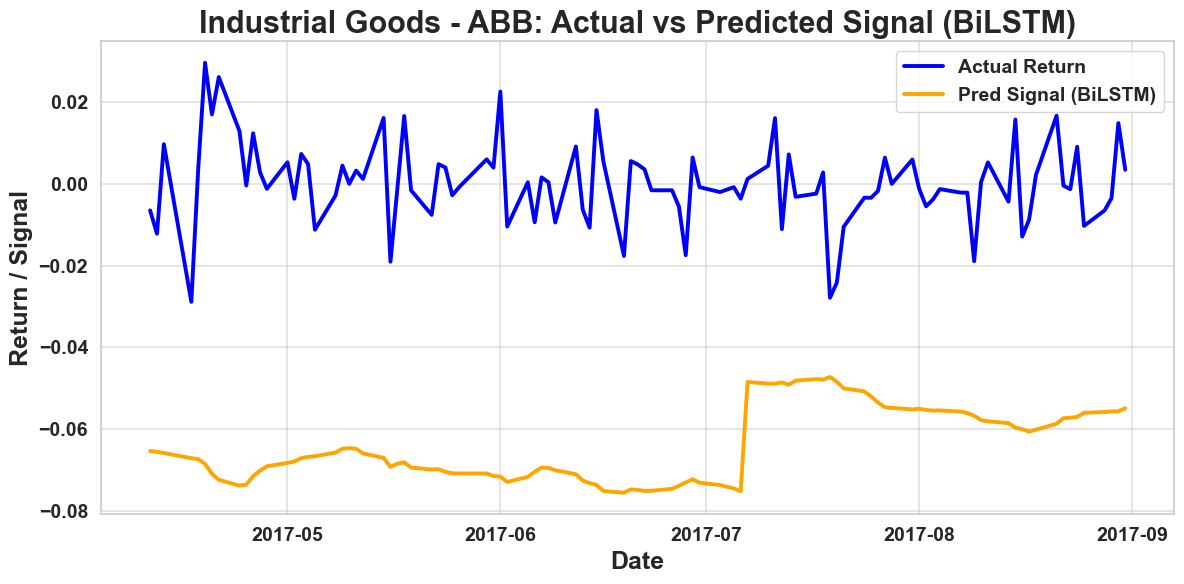

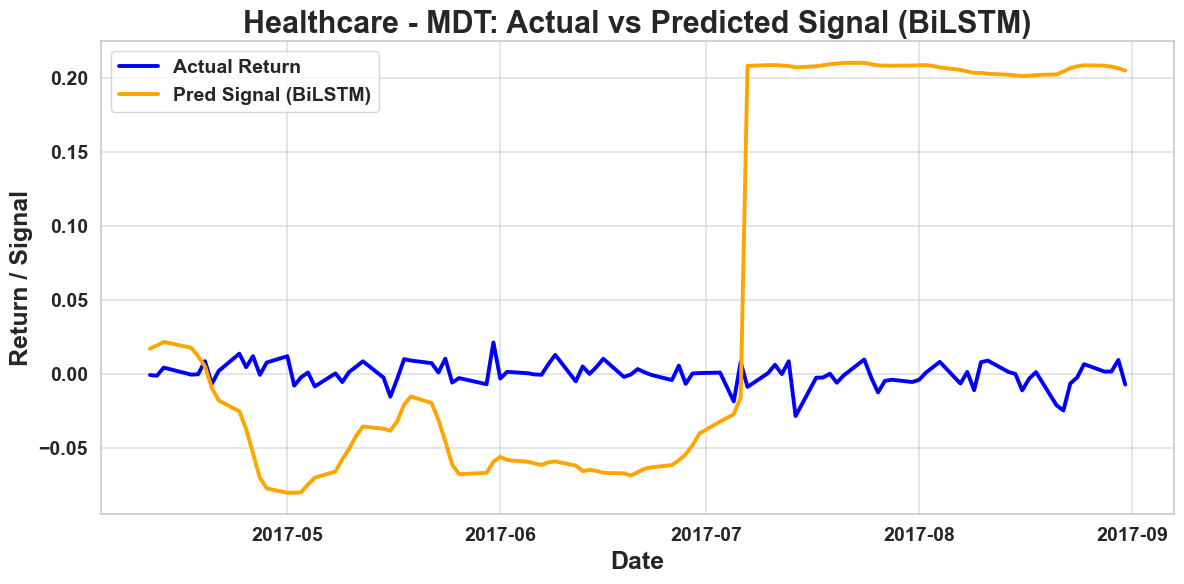

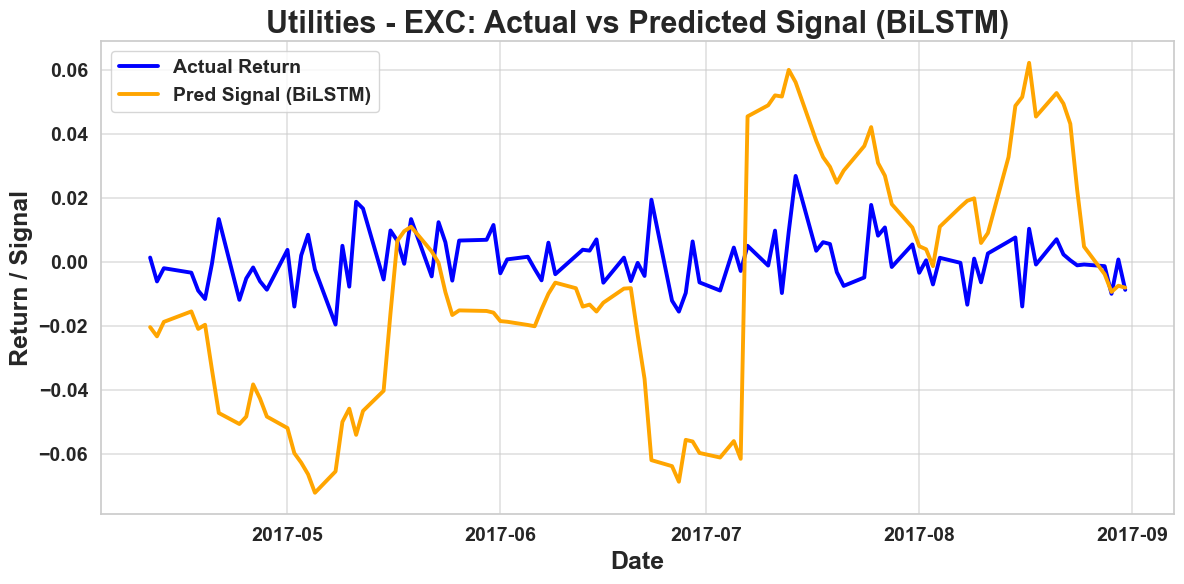

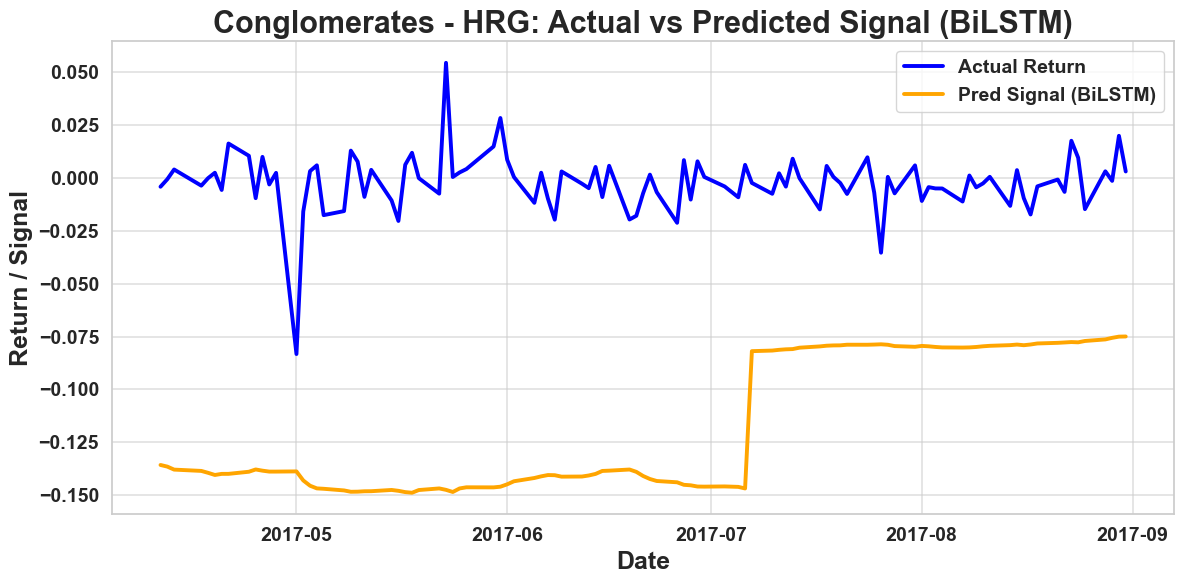

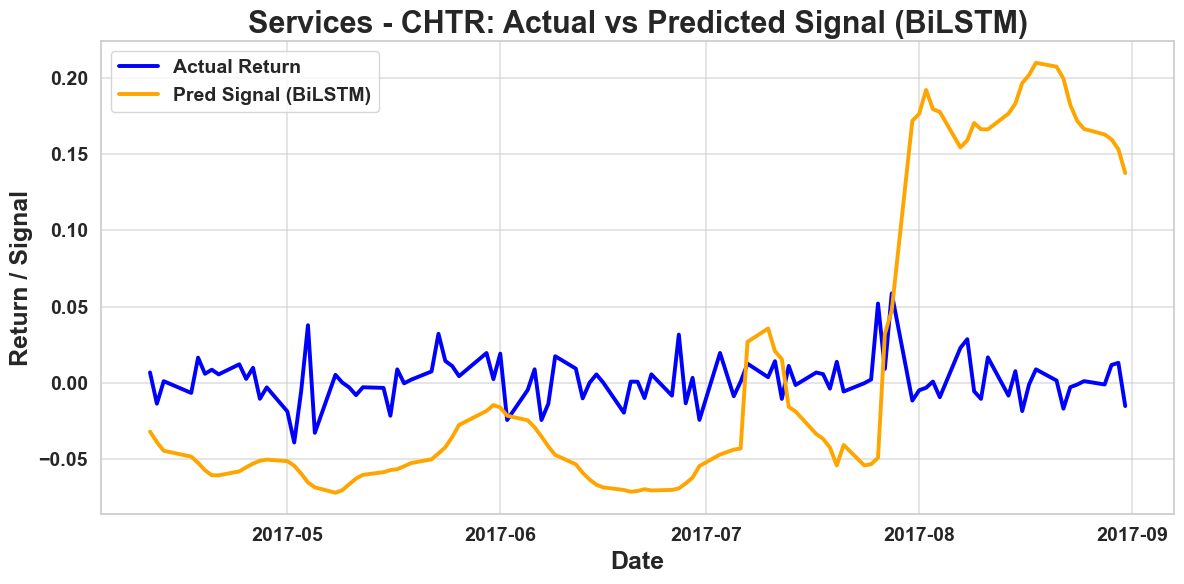

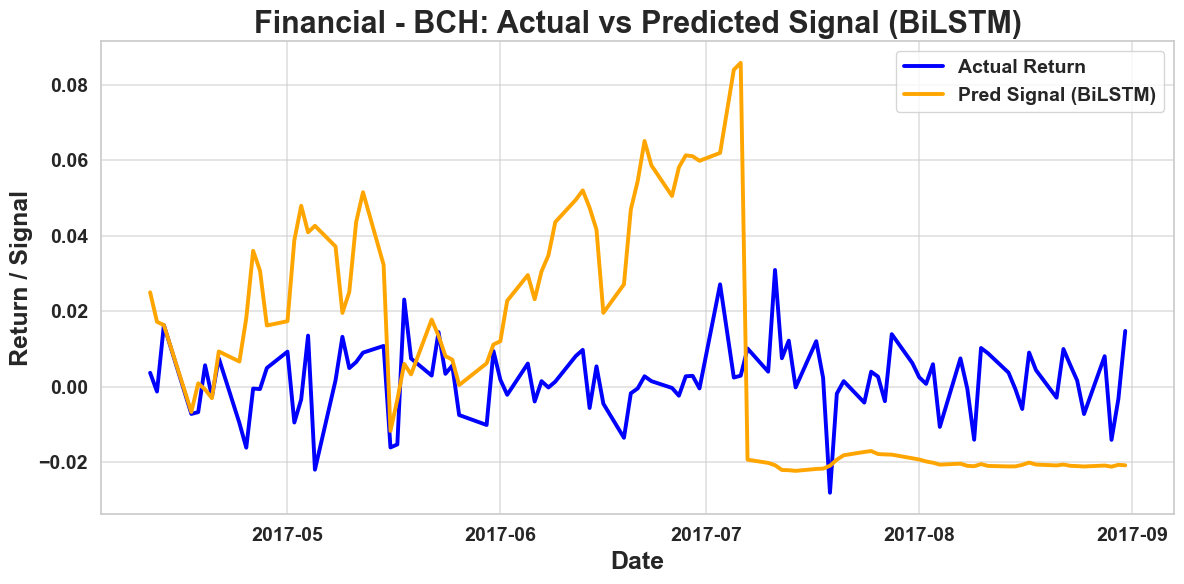

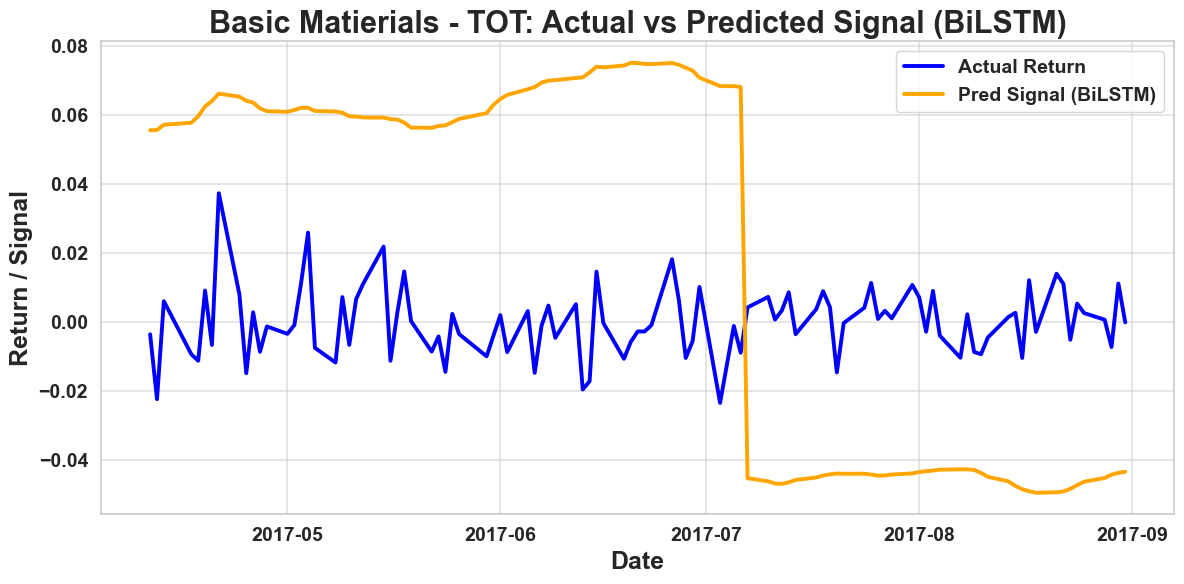

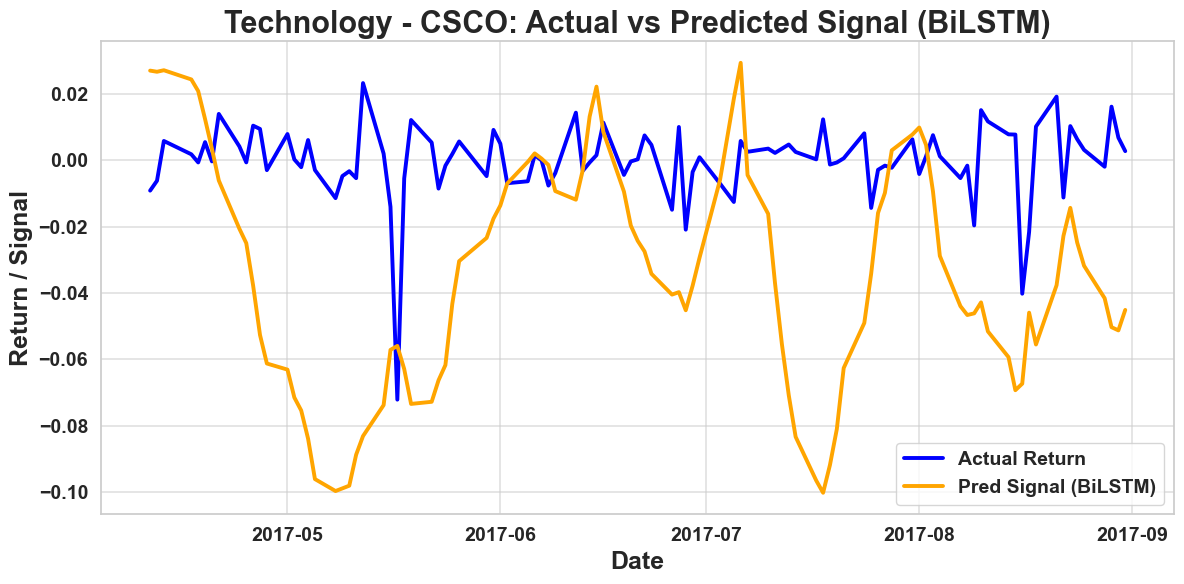

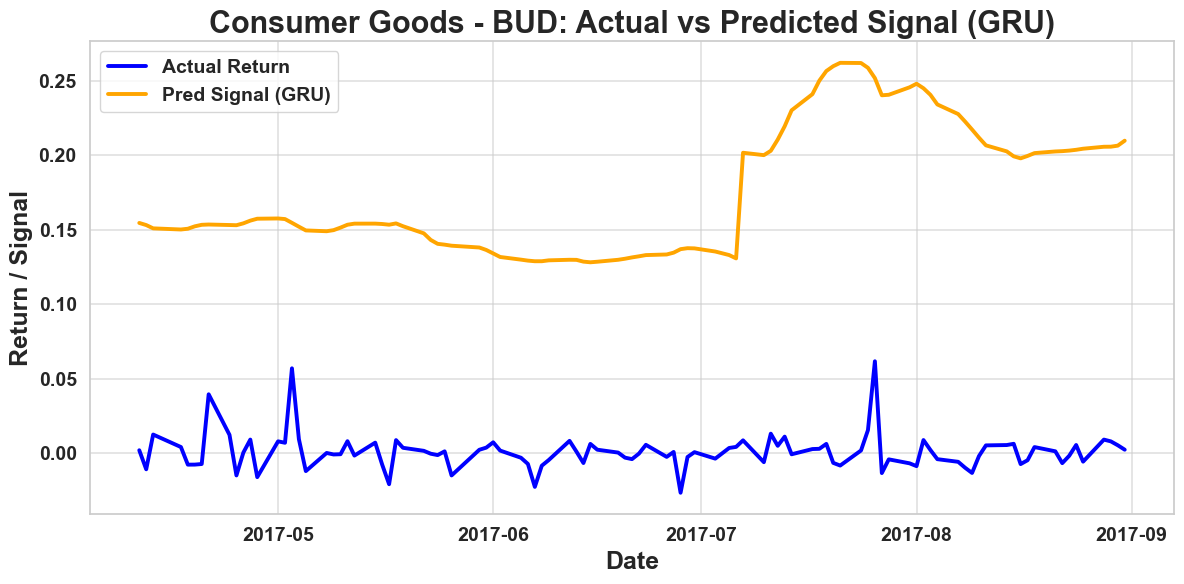

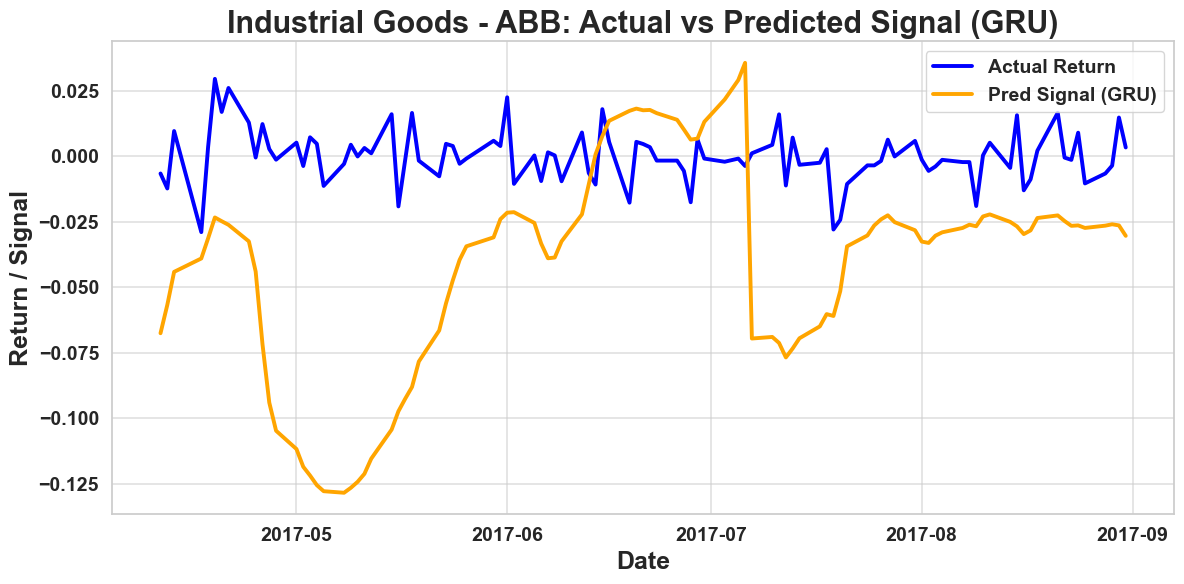

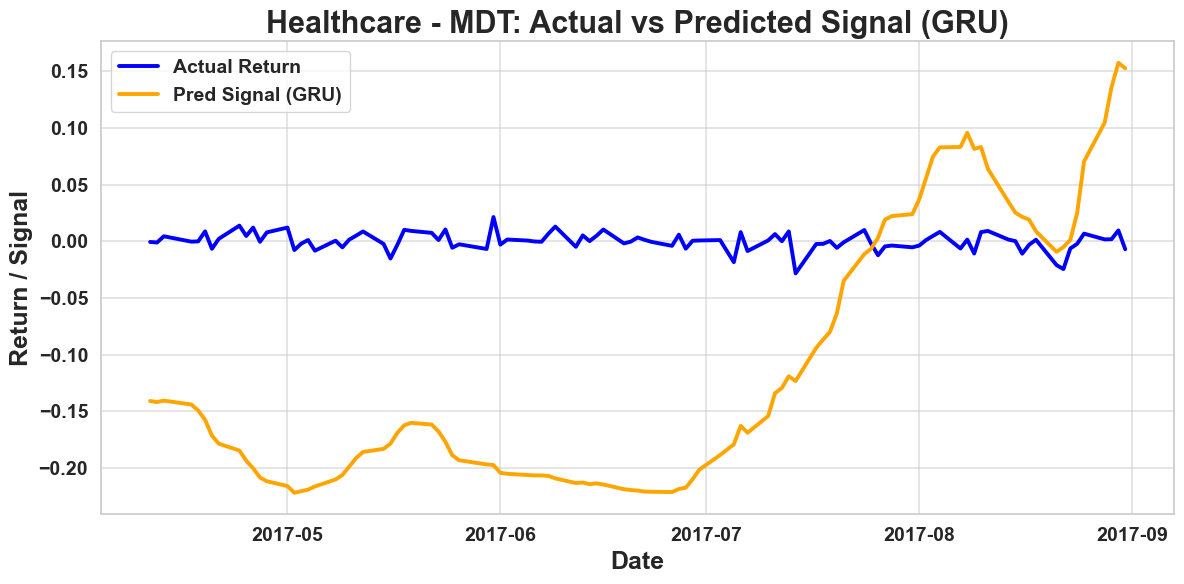

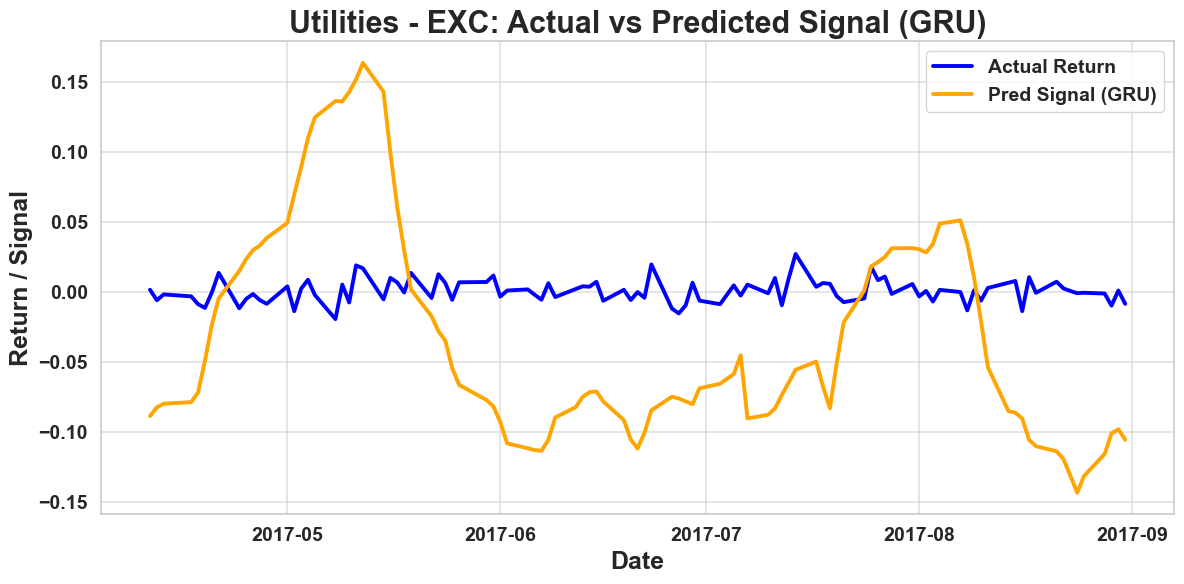

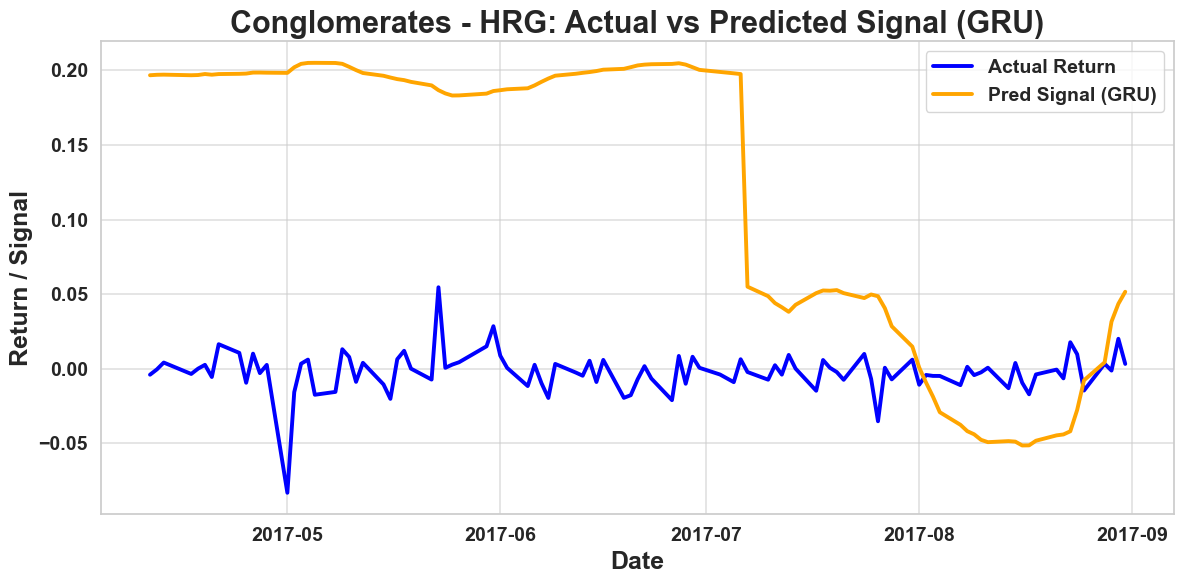

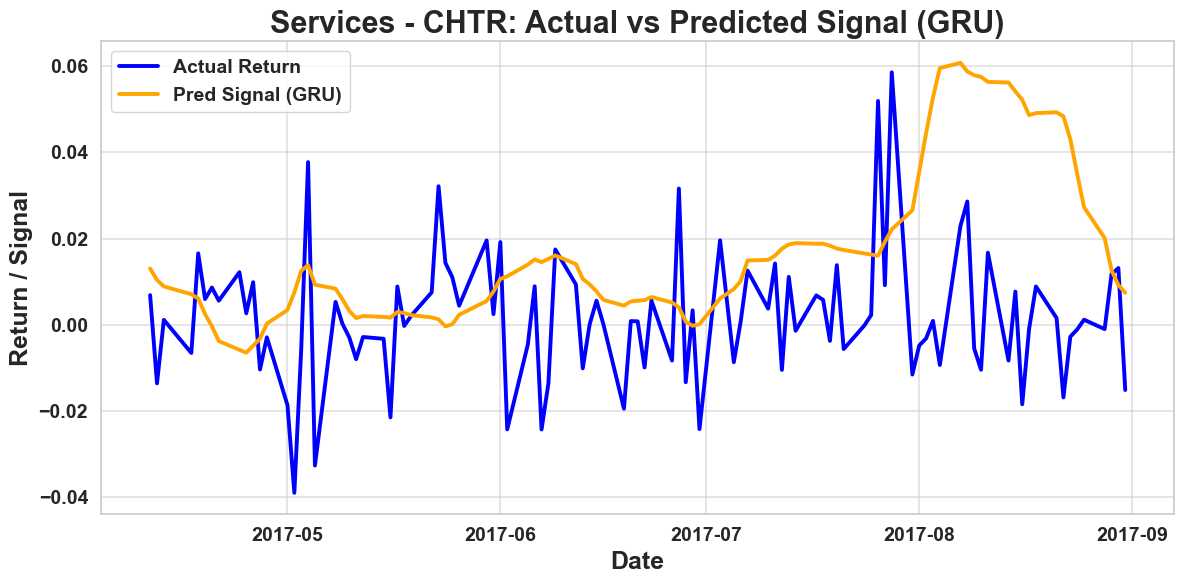

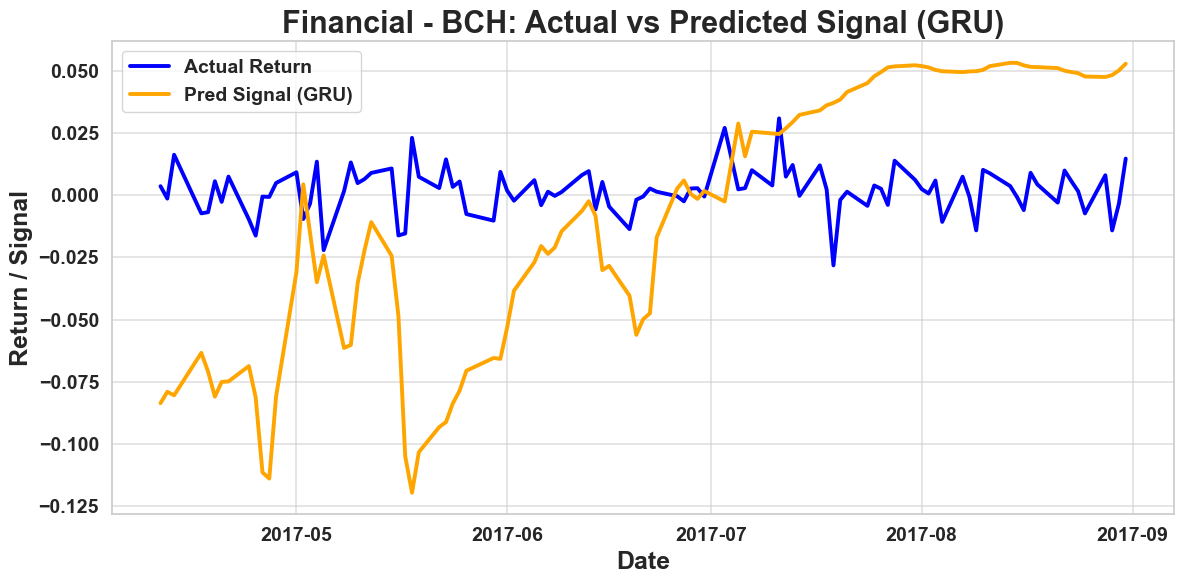

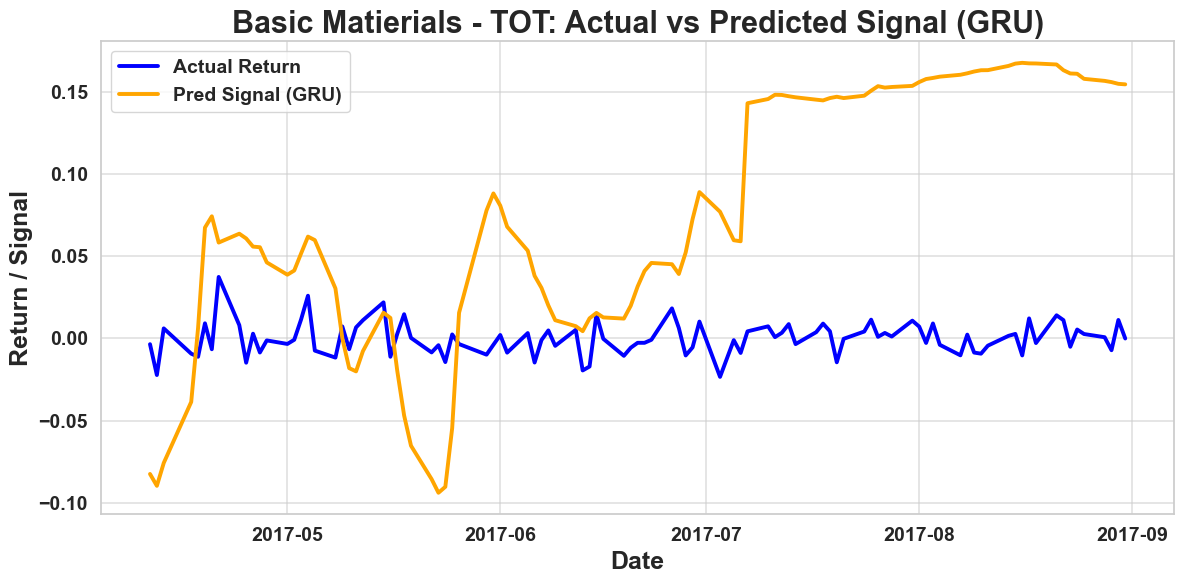

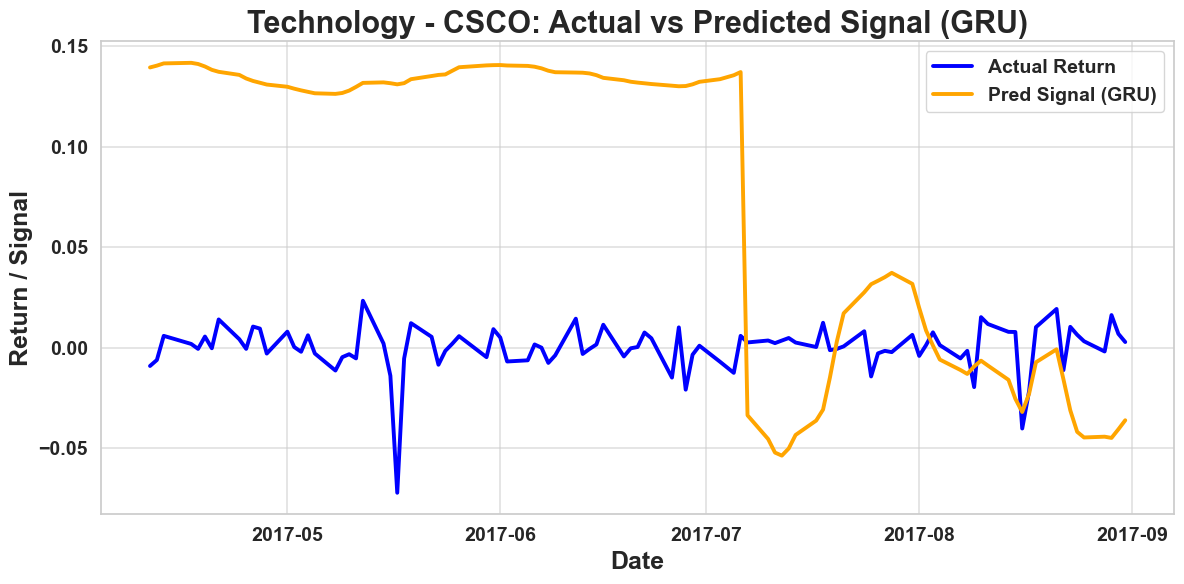

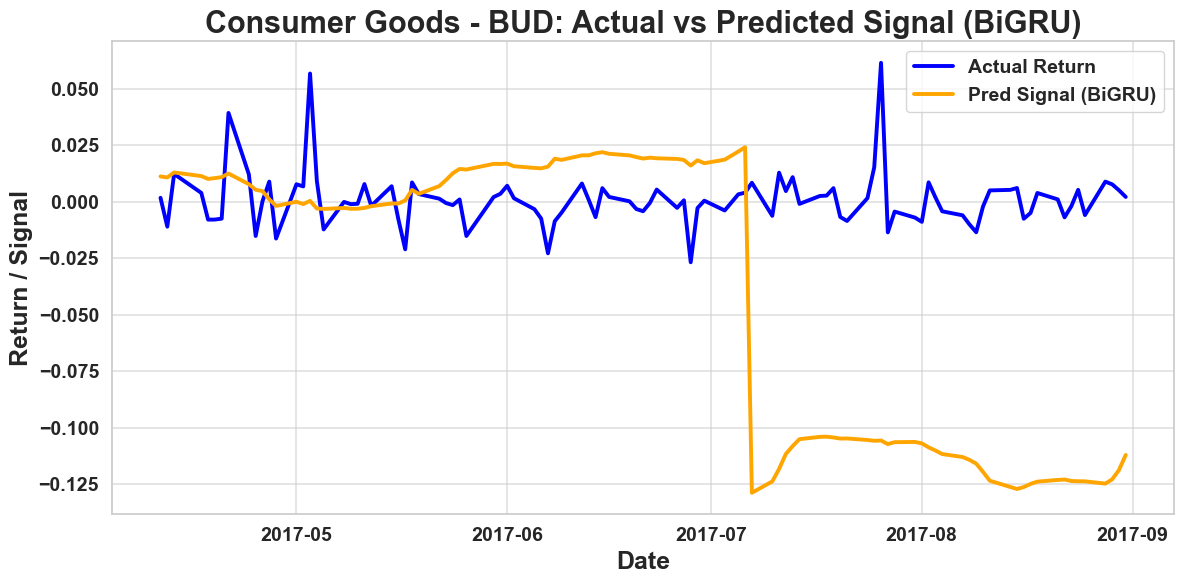

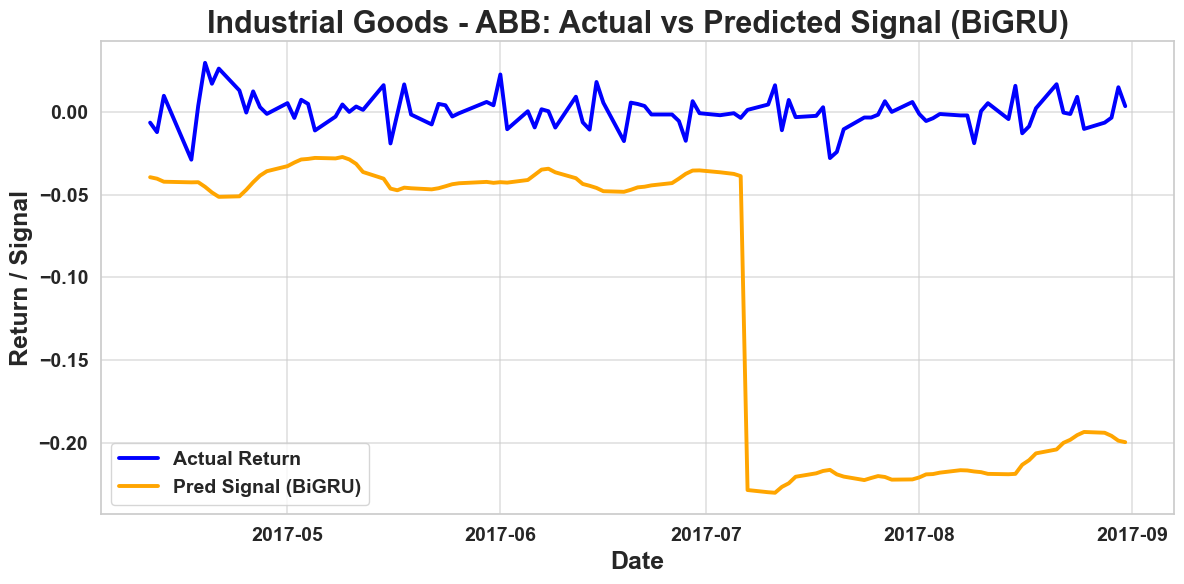

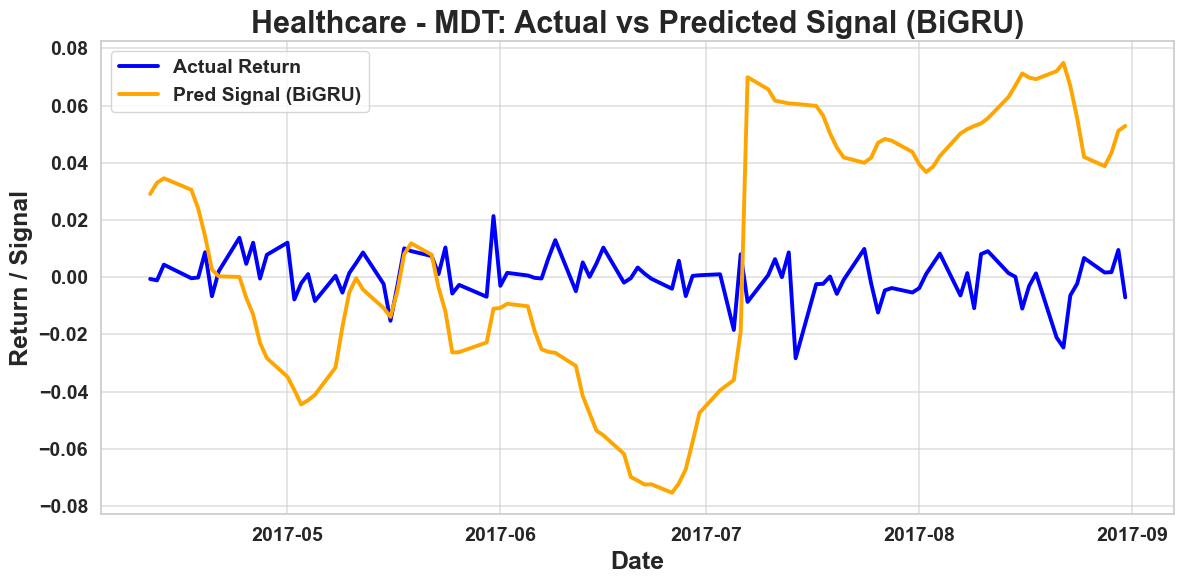

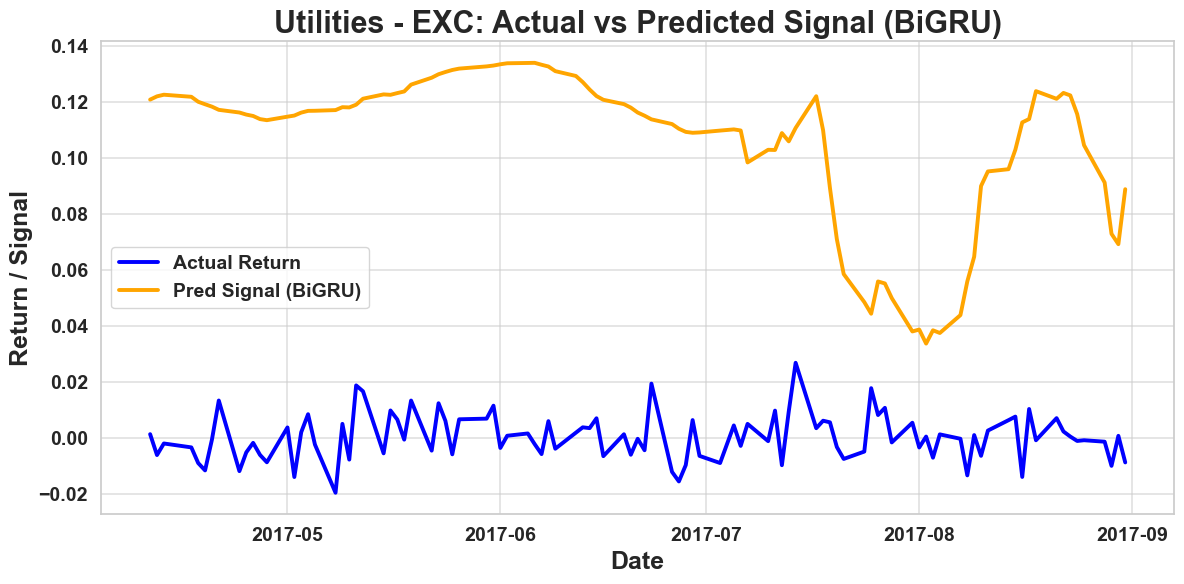

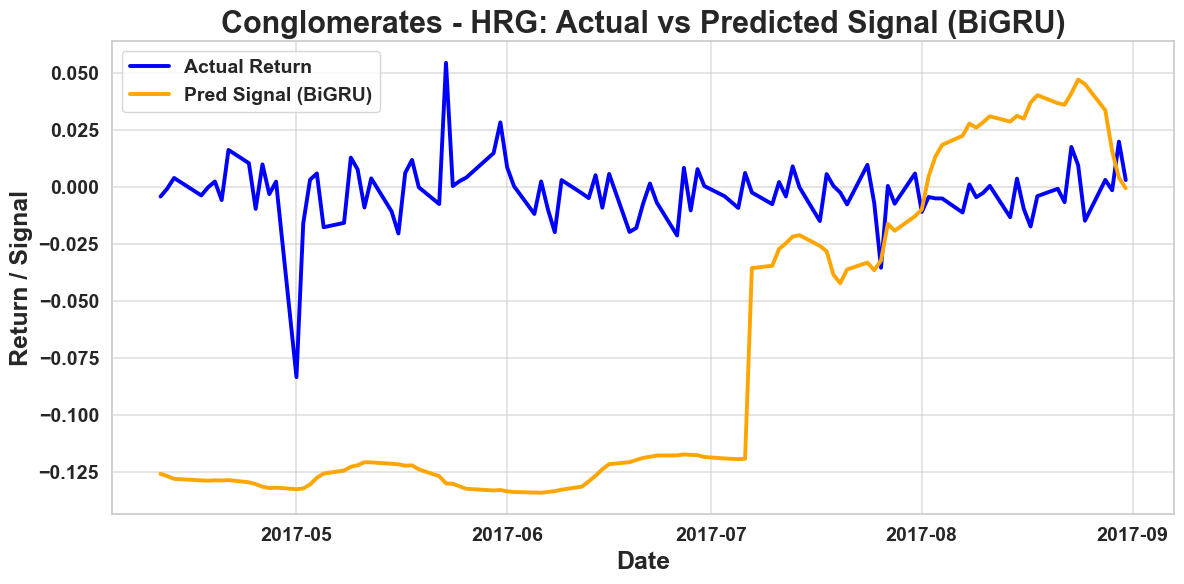

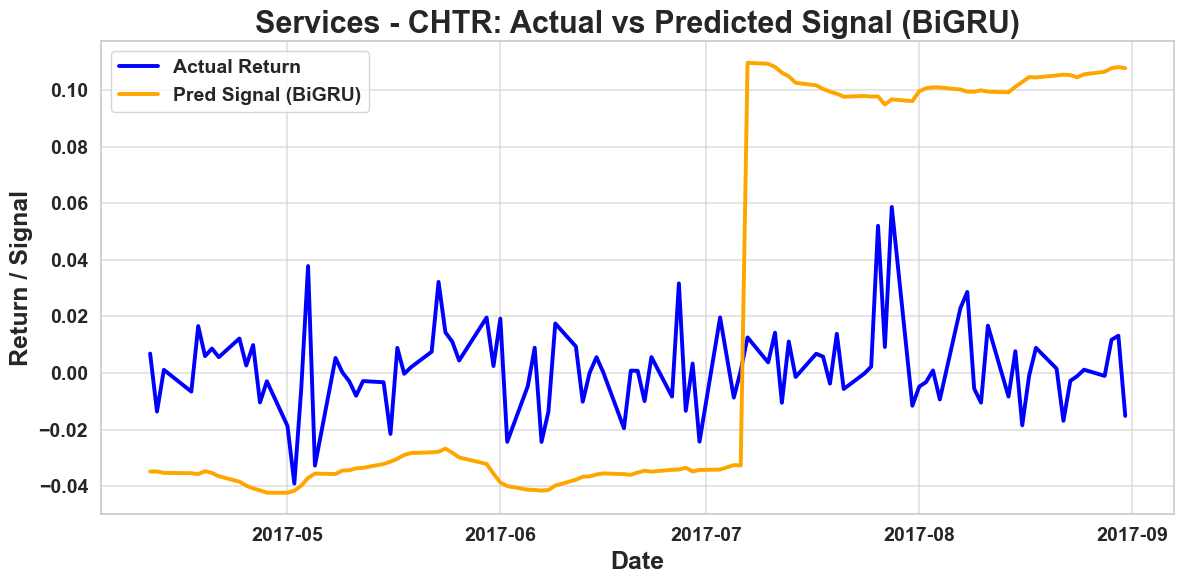

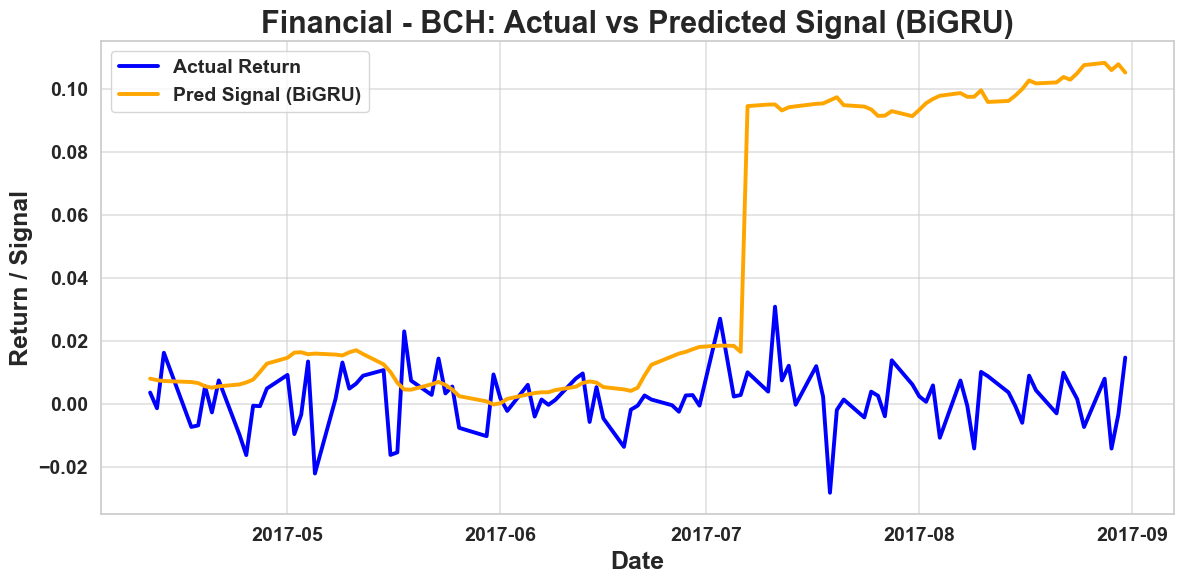

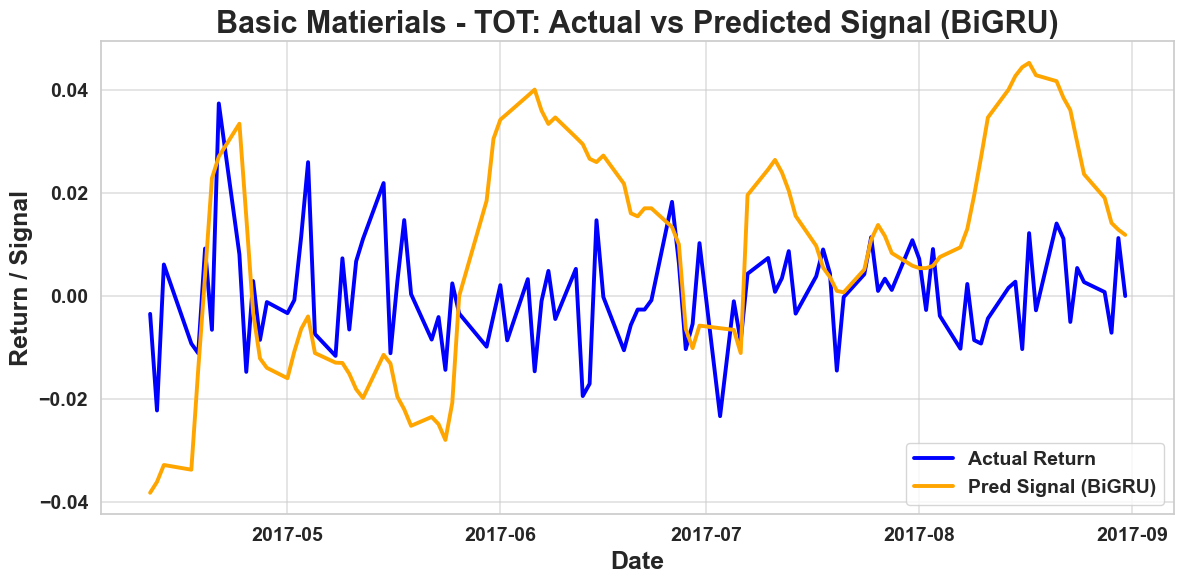

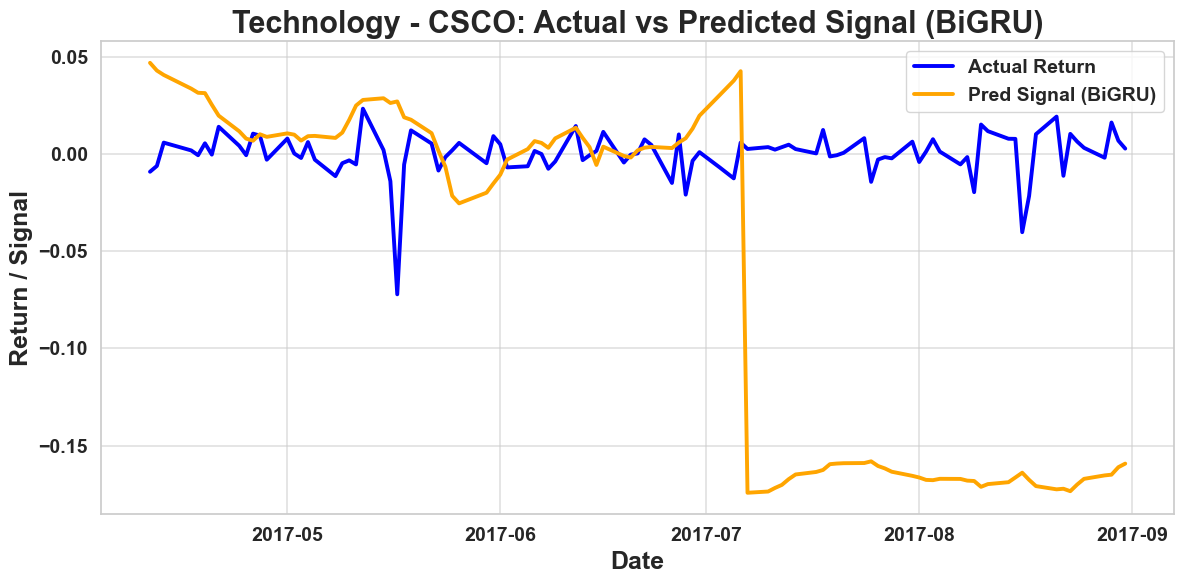

In [13]:
# Compare early-exit regression-style signal vs actual 1D return (all models)

MASTER_PATH = Path('../data/dataset/master_df.parquet')
if not MASTER_PATH.exists():
    print('master_df.parquet not found; skipping plot.')
else:
    master_df = pd.read_parquet(MASTER_PATH)
    master_df = master_df.sort_values(['ticker', 'date']).copy()
    master_df['ret_1d'] = master_df.groupby('ticker')['close'].shift(-1) / master_df['close'] - 1.0

    candidate_models = ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']
    models = [m for m in candidate_models if f'reg_dir_{m}' in exit_df.columns and f'reg_conf_{m}' in exit_df.columns]
    if not models:
        print('No regression direction/confidence columns found.')
    else:
        df = exit_df.merge(master_df[['date', 'ticker', 'ret_1d', 'sector']], on=['date', 'ticker'], how='left')
        df = df.dropna(subset=['ret_1d', 'sector'])
        if df.empty:
            print('No rows after merge/dropna.')
        else:
            random.seed(42)
            sector_ticker_map = {}
            for sector in df['sector'].dropna().unique():
                tickers = df.loc[df['sector'] == sector, 'ticker'].dropna().unique()
                if len(tickers):
                    sector_ticker_map[sector] = random.choice(tickers)

            for m in models:
                dir_col = f'reg_dir_{m}'
                conf_col = f'reg_conf_{m}'
                df_m = df.dropna(subset=[dir_col, conf_col])
                if df_m.empty:
                    print(f'No rows for model {m}')
                    continue

                df_m = df_m.copy()
                df_m['pred_ret'] = df_m[dir_col] * df_m[conf_col]

                for sector, ticker in sector_ticker_map.items():
                    stock_data = df_m[df_m['ticker'] == ticker].sort_values('date')
                    if stock_data.empty:
                        continue

                    fig, ax = plt.subplots(figsize=(12, 6))
                    ax.plot(stock_data['date'], stock_data['ret_1d'], label='Actual Return', color='blue', linewidth=2.8)
                    ax.plot(stock_data['date'], stock_data['pred_ret'], label=f'Pred Signal ({m})', color='orange', linewidth=2.8)

                    ax.set_title(
                        f'{sector} - {ticker}: Actual vs Predicted Signal ({m})',
                        fontsize=22,
                        fontweight='bold'
                    )
                    ax.set_xlabel('Date', fontsize=18, fontweight='bold')
                    ax.set_ylabel('Return / Signal', fontsize=18, fontweight='bold')

                    ax.tick_params(axis='both', labelsize=14, width=2)
                    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                        lbl.set_fontweight('bold')

                    leg = ax.legend(fontsize=14, frameon=True)
                    for txt in leg.get_texts():
                        txt.set_fontweight('bold')

                    ax.grid(True, linewidth=1.2, alpha=0.6)
                    plt.tight_layout()
                    plt.show()


NameError: name 'condition_df' is not defined